In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [2]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path


# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_ant_1_el,
    Calcul_T_ant_2,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
)

# import pratique - mc_tools
from src.cosmo_lidar.mc_tools import (
    generate_Pwater_MC,
    generate_Pwater_MC_lognormal,
    monte_carlo_t_ant,
    calcul_snr,
    remove_nans,
    Monte_Carlo_T_ant_mod,
    local_bin_width,
    scale_snr_for_variable_bins,
    predict_SNR_T,
    hybrid_lin_geom,
)

# import pratique - io
from src.cosmo_lidar.io import (
    fetch_html,
    extract_ut_column_dat_links,
    download_some,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    load_parquet_columns_as_numpy,
    to_float64,
)

import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid
from matplotlib import pyplot as plt
import pandas as pd

test sur z_moy

In [15]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
#on va calculer la temperature d'antenne
pi = np.pi     
frequency = np.linspace(100.e9 , 600.e9 , 800) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 15001, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

In [16]:

#valeur de predict SNR sur le fichier de patrick 90°, 50cm mirror
A = 106533.049
c = 1.470303e-05
R_water = 461.5 #J/(kg*K)
R_d_air = 287 #J/(kg*K)
espilon = R_d_air/R_water

WVMR = (P_water*100)/(Pressure*100 - P_water*100) * espilon * 1000 #en g/kg
elev = 45 #degrees

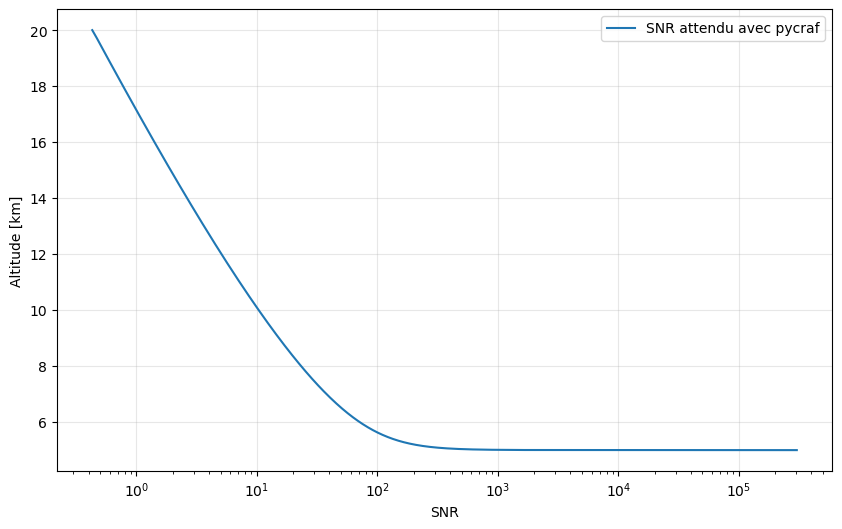

In [17]:
snr_attendu_ref = calcul_snr(A, c, WVMR, altitudes, Pressure, Temperature, elev) #modèle ajusté avec patrick
snr_attendu = scale_snr_for_variable_bins(altitudes, snr_attendu_ref, elev, dz_ref=30.0) [0]
plt.figure(figsize=(10,6))
plt.plot(snr_attendu, altitudes/1e3, label="SNR attendu avec pycraf")
plt.xlabel("SNR")
plt.xscale("log")
plt.ylabel("Altitude [km]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
PWV = trapezoid(rho_water, altitudes)/1e3  #en mm
print(f"PWV = {PWV} mm")
z_moy = trapezoid(altitudes * rho_water/1e3, altitudes)/PWV #en m
print(f"z_moy = {z_moy} m")

PWV = 1.2306686805676852 mm
z_moy = 6991.685135090512 m


In [19]:
N_MC = 1000
rel_sigma = 1/snr_attendu

WVMR_MC = generate_Pwater_MC_lognormal(WVMR, N_MC, rel_sigma, rng=None)

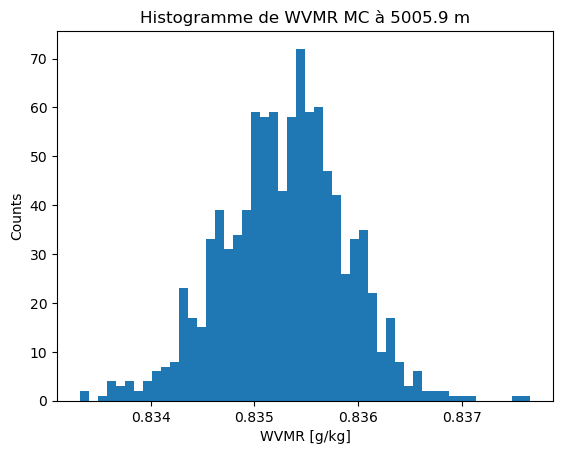

In [20]:
plt.hist(WVMR_MC[:,100], bins=50)
plt.xlabel("WVMR [g/kg]")
plt.ylabel("Counts")
plt.title(f"Histogramme de WVMR MC à {altitudes[100]:.1f} m")
plt.show()

In [27]:
rho_water_MC = Pressure*100*WVMR_MC/(1000*R_d_air*Temperature)*1/(1+R_water/R_d_air*WVMR_MC/1000) #en kg/m3
# PWV: (N_MC,)
PWV_MC = trapezoid(rho_water_MC, altitudes, axis=1)  # (unités selon altitudes)

# z_moy: (N_MC,)
z_moy_MC = trapezoid(rho_water_MC * altitudes[None, :], altitudes, axis=1) / PWV_MC

# std_z: (N_MC,)
dz2 = (altitudes[None, :] - z_moy_MC[:, None])**2
std_z_MC = np.sqrt(trapezoid(dz2 * rho_water_MC, altitudes, axis=1) / PWV_MC)

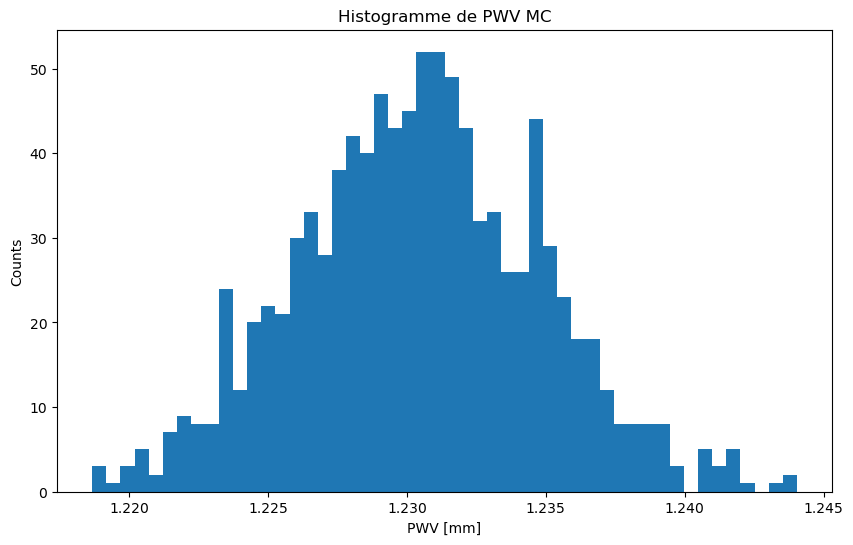

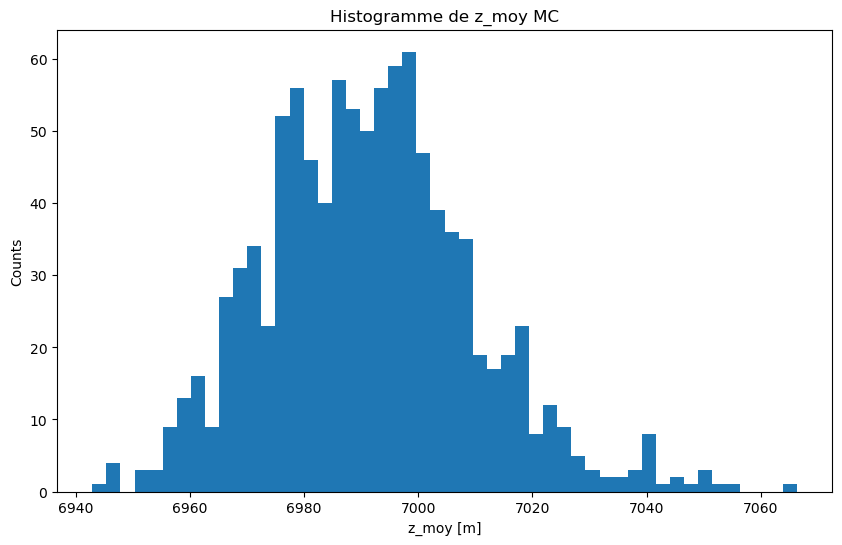

In [28]:
plt.figure(figsize=(10,6))
plt.hist(PWV_MC, bins=50)
plt.xlabel("PWV [mm]")
plt.ylabel("Counts")
plt.title("Histogramme de PWV MC")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(z_moy_MC, bins=50)
plt.xlabel("z_moy [m]")
plt.ylabel("Counts")    
plt.title("Histogramme de z_moy MC")
plt.show()

In [29]:
z_moy_mean = np.mean(z_moy_MC)
z_moy_std = np.std(z_moy_MC, ddof=1)

PWV_mean = np.mean(PWV_MC)
PWV_std = np.std(PWV_MC, ddof=1)

print(f"PWV = {PWV_mean:.2f} ± {PWV_std:.4f} mm")
print(f"z_moy = {z_moy_mean:.2f} ± {z_moy_std:.2f} m")

PWV = 1.23 ± 0.0044 mm
z_moy = 6991.42 ± 18.26 m


In [26]:
std_z_mean = np.mean(std_z_MC)
std_z_std = np.std(std_z_MC, ddof=1)

print(f"std_z = {std_z_mean:.2f} ± {std_z_std:.2f} m")

std_z = 1968.31 ± 35.48 m


In [38]:
from src.cosmo_lidar.mc_tools import Monte_Carlo_PWV_zmoy_stdz

altitudes = np.geomspace(1, 6001, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

R_water = 461.5 #J/(kg*K)
R_d_air = 287 #J/(kg*K)
espilon = R_d_air/R_water

WVMR = (P_water*100)/(Pressure*100 - P_water*100) * espilon * 1000 #en g/kg
elev = 45 #degrees

N_MC = 500

std_PWV, PWV_mean, std_zmoy, zmoy_mean, std_stdz, stdz_mean = Monte_Carlo_PWV_zmoy_stdz(WVMR, altitudes, N_MC, Temperature, Pressure, elev)

In [39]:
print(f"PWV = {PWV_mean:.2f} ± {std_PWV:.4f} mm")
print(f"z_moy = {zmoy_mean:.2f} ± {std_zmoy:.2f} m")
print(f"std_z = {stdz_mean:.2f} ± {std_stdz:.2f} m")

PWV = 1.17 ± 0.0032 mm
z_moy = 6685.20 ± 6.78 m
std_z = 1418.99 ± 6.46 m


Test avec C_tel(z)

In [11]:
#definition des variables

pi = np.pi     
frequency = np.array([ 150.e9]) #Hz
wavelength = 3.e8 / frequency #m
#theta_b = np.array([17*pi/(2*180*3600), 1*60*pi/(2*180*3600), 9*60*pi/(2*180*3600)]) #rad
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
w_0 = wavelength / (pi*theta_b) #m
altitudes = np.arange(0.001, 100, 0.1) #m
theta_graph = np.linspace (-5*theta_b, 5*theta_b,1000) 
L = -0.0065 #K/m le gradient thermique (laspe rate)
T_0 = 288.15 #K température au niveau de la mer
elevation_90 = 90

elevation_45 = 45

N = 500

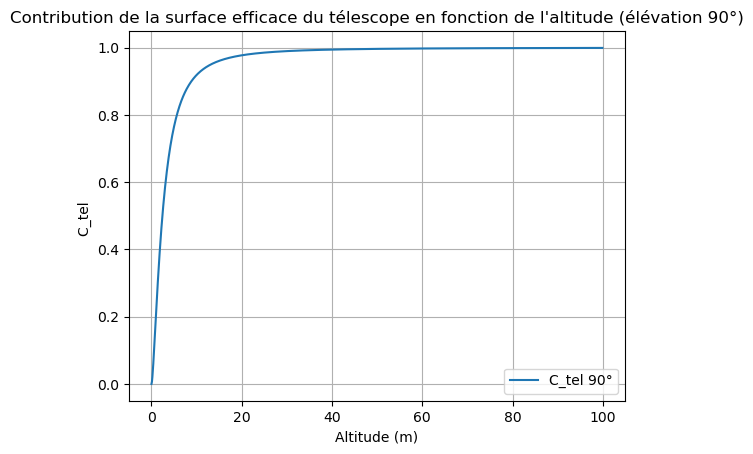

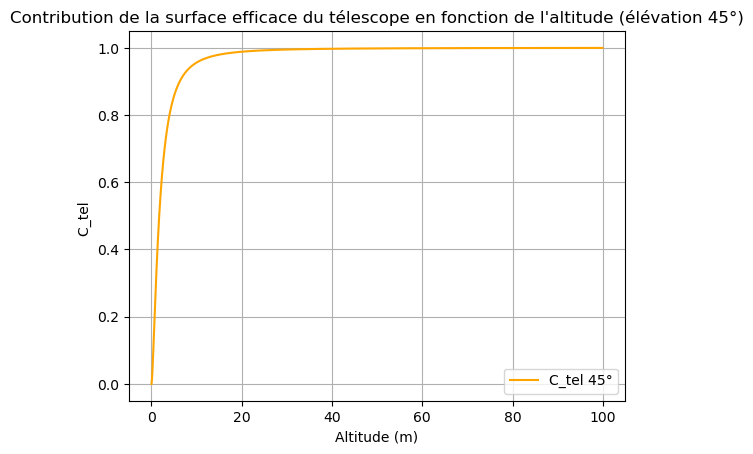

In [12]:
C_tel_90 = contribution_effective_area(frequency,theta_b,altitudes, elevation_90, N)


plt.plot(altitudes, C_tel_90, label='C_tel 90°')
plt.xlabel('Altitude (m)')
plt.ylabel('C_tel ')
plt.title('Contribution de la surface efficace du télescope en fonction de l\'altitude (élévation 90°)')
plt.legend()
plt.grid()
plt.show()

C_tel_45 = contribution_effective_area(frequency,theta_b,altitudes, elevation_45, N)

plt.plot(altitudes, C_tel_45, label='C_tel 45°', color='orange')
plt.xlabel('Altitude (m)')
plt.ylabel('C_tel ')        
plt.title('Contribution de la surface efficace du télescope en fonction de l\'altitude (élévation 45°)')
plt.legend()
plt.grid()
plt.show()



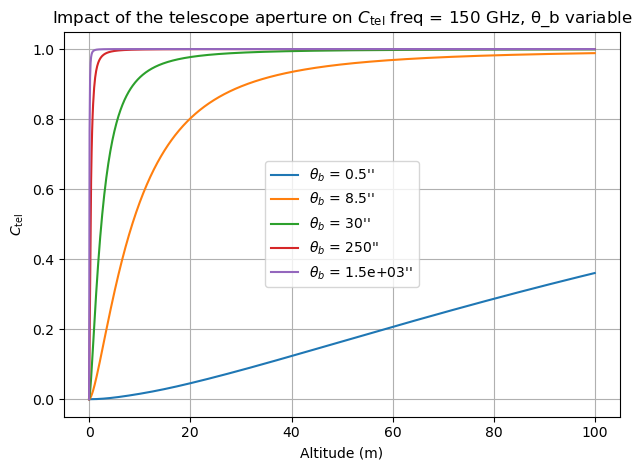

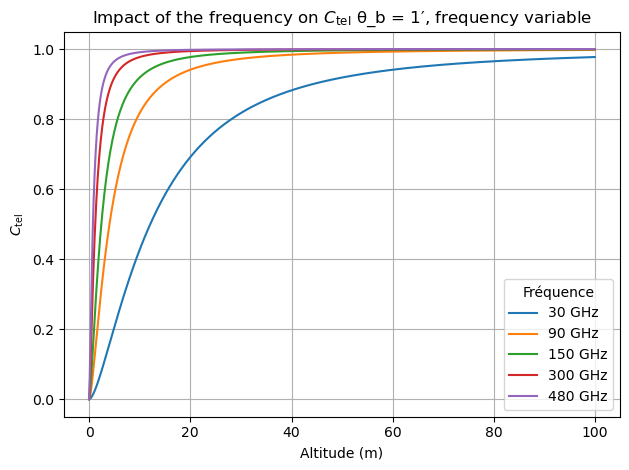

In [ ]:
pi = np.pi
altitudes = np.arange(0.001, 100, 0.1)   # m
elevation_90 = 90                         # deg
# N supposé connu dans ton code :
# N = ...

# ==============================
# 1) Fréquence FIXE, plusieurs θ_b
# ==============================

# Exemple d’ouvertures : 17", 1', 9' (en radians)
arcsec = pi / (180 * 3600)
arcmin = 60 * arcsec
theta_b_values = np.array([1*arcsec/2,17 * arcsec/2, 60 * arcsec/2, 500 * arcsec/2,3000 * arcsec/2])

frequency_fixed = np.full(len(theta_b_values), 150.e9)

C_tel = contribution_effective_area(frequency_fixed, theta_b_values, altitudes, elevation_90, N)
i=0
plt.figure()
for theta_b in theta_b_values:
    
    label = fr"$\theta_b$ = {theta_b/arcsec:.3g}''"  # affiche en arcmin
    plt.plot(altitudes, C_tel[:,i], label=label)
    i+=1

plt.xlabel('Altitude (m)')
plt.ylabel(r'$C_{\rm tel}$')
plt.title(r"Impact of the telescope aperture on $C_{\rm tel}$ freq = 150 GHz, θ_b variable")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# 2) θ_b FIXE, plusieurs fréquences
# ==============================

frequencies = np.array([30e9, 90e9, 150e9, 300e9, 480e9])  # Hz (exemples usuels)

theta_b_fixed = np.full(len(frequencies), 1*60*pi/(2*180*3600))
C_tel = contribution_effective_area(frequencies, theta_b_fixed, altitudes, elevation_90, N)
j=0
plt.figure()
for f in frequencies:
    
    plt.plot(altitudes, C_tel[:,j], label=f"{f/1e9:.0f} GHz")
    j+=1

plt.xlabel('Altitude (m)')
plt.ylabel(r'$C_{\rm tel}$')
plt.title(r"Impact of the frequency on $C_{\rm tel}$ θ_b = 1′', frequency variable")
plt.legend(title='Fréquence')
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
print(frequency_fixed)

[1.5e+11 1.5e+11 1.5e+11 1.5e+11 1.5e+11]


In [3]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
#on va calculer la temperature d'antenne
pi = np.pi     
frequency = np.linspace(100.e9 , 600.e9 , 800) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 5001, 1000) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0] #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1] #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2] #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3] #en hPa

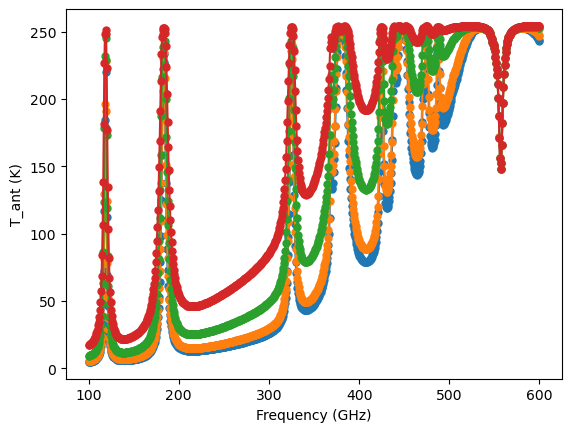

In [4]:
#Ccalcul de T_ant à différents angles d'élévation
elevations = [90, 60, 30, 15]
T_ant_all = {}
for elev in elevations:
    T_ant = Calcul_T_ant_1_el(frequency,theta_b, altitudes, Temperature.value, Pressure.value, P_water.value, elev)
    T_ant_all[elev] = T_ant
    plt.plot(frequency*1.e-9, T_ant, marker='o', markersize=5, label='{elev}')
plt.ylabel("T_ant (K)")
plt.xlabel("Frequency (GHz)")
#plt.title("Antenna temperature at various elevations")
#plt.legend()
#plt.grid(True)
#plt.tight_layout()
plt.show()

In [6]:
f=np.array([150.e9]) #Hz
theta_b_f = np.full(len(f), 1*60*pi/(2*180*3600))
elevation_f = 90
PWV = 1.13
x = np.linspace(0.01, 10, 100)
PWV_x = x * PWV
T_ant_test = np.zeros_like(x)
i=0
for val in x :
    
    P_water_test = P_water * (val)
    T_ant_test[i] = Calcul_T_ant_1_el(f,theta_b_f, altitudes, Temperature.value, Pressure.value, P_water_test.value, elevation_f)
    i=i+1


/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_22732/478979385.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_ant_test[i] = Calcul_T_ant_1_el(f,theta_b_f, altitudes, Temperature.value, Pressure.value, P_water_test.value, elevation_f)


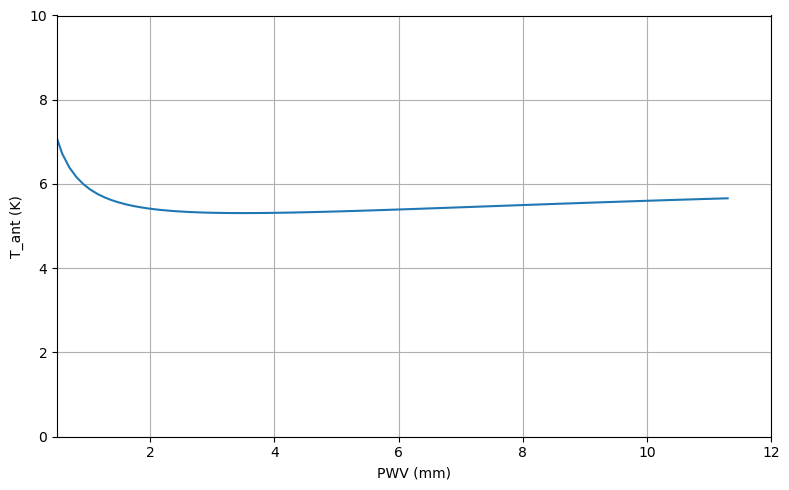

In [17]:
plt.figure(figsize=(8,5))
plt.plot(PWV_x, T_ant_test/PWV_x)
plt.xlabel("PWV (mm)")
plt.xlim(0.5, 12)
plt.ylim(0,10)
plt.ylabel("T_ant (K)")
#plt.title("Antenna temperature at 150 GHz vs PWV")
plt.grid(True)
plt.tight_layout()
plt.show() 

In [25]:
f=np.array([150.e9]) #Hz
theta_b_f = np.full(len(f), 1*60*pi/(2*180*3600))
elevation_f = 90
PWV = 1.13
x = np.linspace(0.22, 1, 50)
elevation_x = x *  elevation_f
T_ant_test_2 = np.zeros_like(x)
i=0
for val in elevation_x :
    
    
    T_ant_test_2[i] = Calcul_T_ant_1_el(f,theta_b_f, altitudes, Temperature.value, Pressure.value, P_water.value, val)
    i=i+1

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_22732/716153449.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_ant_test_2[i] = Calcul_T_ant_1_el(f,theta_b_f, altitudes, Temperature.value, Pressure.value, P_water.value, val)


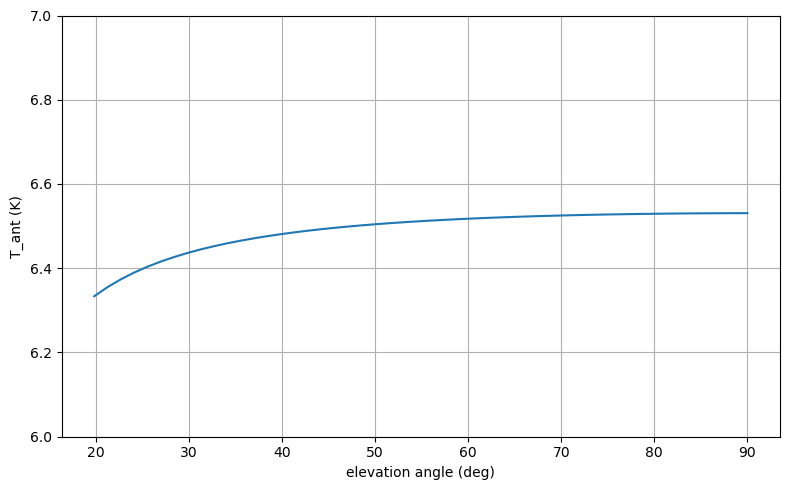

In [28]:
plt.figure(figsize=(8,5))
plt.plot(elevation_x, T_ant_test_2*np.sin(elevation_x*pi/180))
plt.xlabel("elevation angle (deg)")
#plt.xlim(0.5, 12)
plt.ylim(6,7)
plt.ylabel("T_ant (K)")
#plt.title("Antenna temperature at 150 GHz vs PWV")
plt.grid(True)
plt.tight_layout()
plt.show() 

On va faire une estimation du nouveau SNR

In [66]:
#Importation des données d'Octobre

T_acq = 60 #temps d'acquisition (s)
E_0 = 60.e-3 #emission ernergy (J)
F_t = 200 #shooting frequency (Hz)

#pour un angle d'élévation de 90°

e=90 # angle d'élévation (°)
# Charger les données (adapter le nom du fichier et éventuellement le délimiteur)
data_2 = np.loadtxt("/Users/vl284796/Downloads/Simulation_Atakama_lidarH2O_50cm_00.txt")

# Chaque colonne devient un tableau séparé
s_90_2    = data_2[:, 0]  # distance au lidar (km)
z     = data_2[:, 1]  # altitude (km)
WVMR = data_2[:, 2] *1000 # WVMR (g/kg)
noise  = data_2[:, 3]  # écart type (g/kg)
b_rh_90_2 = data_2[:, 4]  # biais (g/kg)
P = data_2[:,5] #Pression en hPa
T = data_2[:,6] #Temperature (K)

SNR = WVMR / noise

"""frequency = np.array([150.e9]) #en Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600)) #en rad
elev = 90 #en
N_MC = 100"""

print(SNR.shape, WVMR.shape, z.shape, P.shape, T.shape)

(167,) (167,) (167,) (167,) (167,)


In [31]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

def fit_snr_model(z, SNR, P, T, WVMR, z0=None):
    """
    Fit des paramètres A et c du modèle :
    
        SNR(z) = (A / (z - z0)) * sqrt(WVMR(z) * P(z) / T(z)) * exp(-c * ∫[z0->z] P/T dz')
    
    Paramètres
    ----------
    z, SNR, P, T, WVMR : np.ndarray 1D de même taille
    z0 : float ou None
        Altitude de référence pour l'intégrale.
        Si None, on prend z0 = z[0] et on enlève le premier point (où z=z0).
    
    Retour
    ------
    A, c : floats
        Paramètres ajustés du modèle.
    SNR_model : np.ndarray
        SNR théorique reconstruit sur tout le profil (même taille que SNR).
    mask_fit : np.ndarray bool
        Masque des points effectivement utilisés pour le fit.
    """

    z = np.asarray(z)
    SNR = np.asarray(SNR)
    P = np.asarray(P)
    T = np.asarray(T)
    WVMR = np.asarray(WVMR)

    # 1) Choix de z0
    if z0 is None:
        z0 = z[0]

    # 2) Calcul des quantités intermédiaires (sur tout le profil)
    # Phi(z) = 1/(z - z0) * sqrt(WVMR * P / T)
    with np.errstate(divide='ignore', invalid='ignore'):
        Phi = 1.0 / (z - z0) * np.sqrt(WVMR * P / T)

    # I(z) = ∫[z0->z] P/T dz  (intégrale cumulative par trapèzes)
    integrand = P / T
    I = cumulative_trapezoid(integrand, z, initial=0.0)

    # 3) Construction du masque de points "propres" pour le fit
    #    - z > z0 pour éviter la division par 0
    #    - SNR > 0 et Phi > 0 (log bien défini)
    #    - valeurs finies (pas de NaN/inf)
    mask_fit = (
        (z > z0) &
        (SNR > 0) &
        (Phi > 0) &
        np.isfinite(SNR) &
        np.isfinite(Phi) &
        np.isfinite(I)
    )

    if np.sum(mask_fit) < 2:
        raise ValueError("Pas assez de points valides pour effectuer le fit.")

    z_fit = z[mask_fit]
    SNR_fit = SNR[mask_fit]
    Phi_fit = Phi[mask_fit]
    I_fit = I[mask_fit]

    # 4) On passe dans le log :
    # Y = ln(SNR / Phi) = ln(A) - c * I
    Y = np.log(SNR_fit / Phi_fit)

    # 5) Régression linéaire Y = a + b * I  =>  a = ln(A), b = -c
    b, a = np.polyfit(I_fit, Y, 1)
    c_est = -b
    A_est = np.exp(a)

    # 6) Reconstruction de la SNR théorique sur tout le profil
    SNR_model = A_est * Phi * np.exp(-c_est * I)

    return A_est, c_est, SNR_model, mask_fit


A = 106533.0494232493
c = 1.4703021446767036e-05


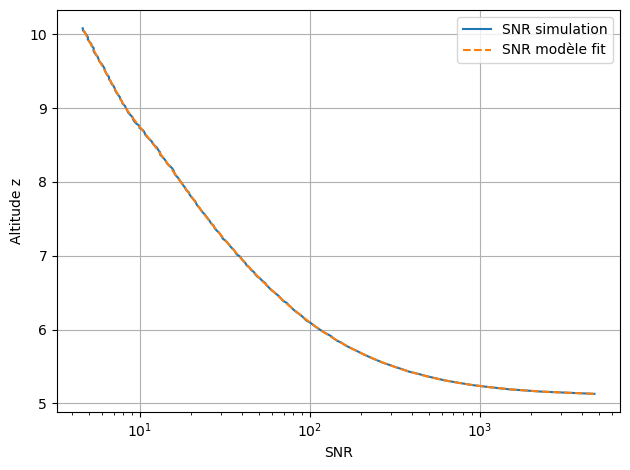

In [40]:
z_m = z*1000  # conversion en m
A, c, SNR_model, mask_fit = fit_snr_model(z_m, SNR, P, T, WVMR)

print("A =", A)
print("c =", c)

# Exemple de comparaison
import matplotlib.pyplot as plt

plt.plot(SNR[1:], z[1:], label="SNR simulation")
plt.plot(SNR_model[1:], z[1:], '--', label="SNR modèle fit")
plt.xlabel("SNR")
plt.xscale("log")
plt.ylabel("Altitude z")
plt.legend()
plt.grid()
plt.tight_layout()
#plt.gca().invert_yaxis()  # si tu veux l'altitude qui monte vers le haut
plt.show()


/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_22732/378788469.py:2: RuntimeWarning: divide by zero encountered in divide
  SNR_test = A*np.sqrt(WVMR * P / T) / (z_m - (z_m[0])) * np.exp(-c_test * cumulative_trapezoid(P / T, z_m, initial=0.0))


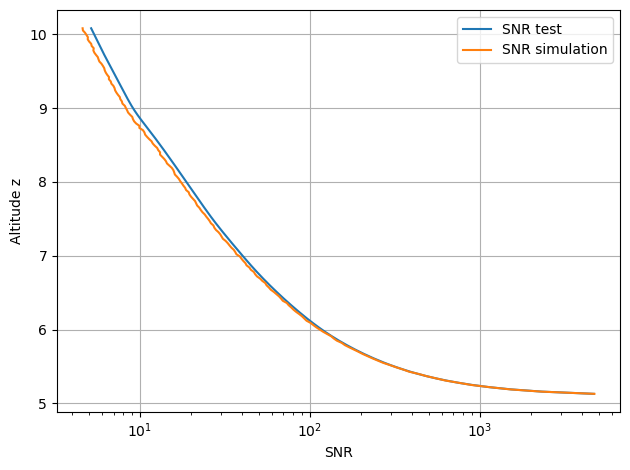

In [ ]:
c_test = c
SNR_test = A*np.sqrt(WVMR * P / T) / (z_m - (z_m[0])) * np.exp(-c_test * cumulative_trapezoid(P / T, z_m, initial=0.0))
plt.plot(SNR_test[1:], z[1:], label="SNR test")
plt.plot(SNR[1:], z[1:], label="SNR simulation")
plt.xlabel("SNR")
plt.xscale("log")
plt.ylabel("Altitude z")
plt.legend()
plt.grid()
plt.tight_layout()
#plt.gca().invert_yaxis()  # si tu veux l'altitude qui monte vers le haut
plt.show()

Essayons d'appliquer ce fit à de vrai valeurs

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
# Lire le fichier .txt


cols = ["TIME", "PMB", "TEMP", "TDEW", "RH", 
        "GEOP", "AZ", "EL", "SPEED", "DIR", 
        "E.TIME", "RT", "Battery"]

df_1 = pd.read_csv('/Users/vl284796/Downloads/data 25 avril.txt', 
                 delim_whitespace=True, 
                 skiprows=1, 
                 names=cols, encoding='latin-1')

time = df_1["TIME"].values
temp = pd.to_numeric(df_1["TEMP"], errors="coerce").values[2:-1780] + 273.15 #en K
alt = pd.to_numeric(df_1["GEOP"], errors="coerce").values[2:-1780] *1.e-3 #en km
rh   = pd.to_numeric(df_1["RH"], errors="coerce").values[2:-1780] #%
T_DEW = pd.to_numeric(df_1["TDEW"], errors="coerce").values[2:-1780] +273.15 # en K
P_data =  pd.to_numeric(df_1["PMB"], errors="coerce").values[2:-1780] #en hPa



R_water = 461.5 #J/(kg·K)

e_1= vapor_pressure(T_DEW) #hPa
r_WVMR_1 = 0.622*e_1/(P_data-e_1) #kg/kg

rho_water = e_1*100/(R_water*temp) #en kg/m3

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/1857597164.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_1 = pd.read_csv('/Users/vl284796/Downloads/data 25 avril.txt',


In [115]:
A = 106533.049 #parameter estimation SNR
c = 1.470303e-05 #parameter estimation SNR
WVMR_1 = r_WVMR_1 [1:] *1000 #g/kg
z_1 = alt[1:] *1000 #m
P_1 = P_data[1:] #hPa
T_1 = temp[1:] #K
P_water_1 = e_1[1:]
SNR_1 = A*np.sqrt(WVMR_1 * P_1 / T_1) / (z_1 - (z_1[0]-0.001)) * np.exp(-c * cumulative_trapezoid(P_1 / T_1, z_1, initial=0.0))

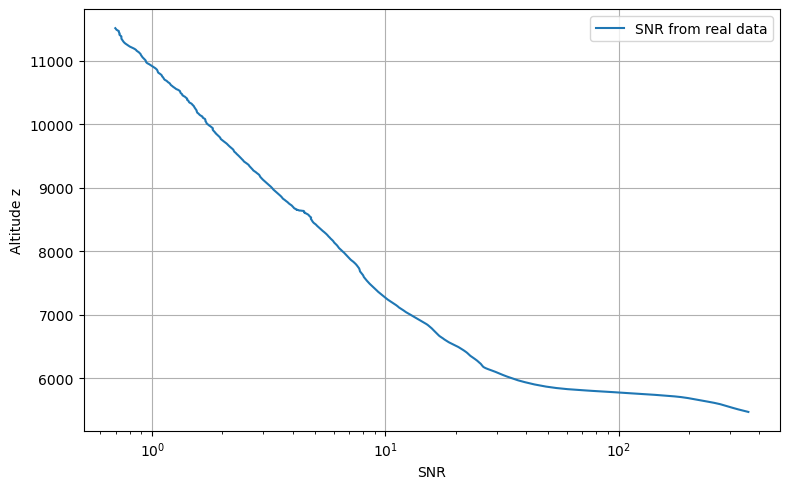

[3.78338832e+04 2.84008784e+04 2.27513107e+04 ... 6.97281126e-01
 6.96409592e-01 6.94958832e-01]


In [108]:
plt.figure(figsize=(8,5))
plt.plot(SNR_1[100:], z_1[100:], label="SNR from real data")
plt.xlabel("SNR")
plt.xscale("log")
plt.ylabel("Altitude z")
plt.legend()   
plt.grid()
plt.tight_layout()
plt.show()

print(SNR_1[3:])

In [70]:
frequency = np.array([150.e9]) #en Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600)) #en rad
elev = 90 #en rad
N_MC = 100
N=500





simu = Monte_Carlo_T_ant_mod(frequency, theta_b, N, elev, generate_Pwater_MC_lognormal, N_MC, WVMR_1, SNR_1, T_1, P_1, z_1)

print(simu)


(np.float64(0.0013281339730611766), array([5.786468]))


In [63]:
print(SNR_1)

[2.27778582e+08 2.27242778e+05 5.67993581e+04 ... 6.97281186e-01
 6.96409652e-01 6.94958892e-01]


In [116]:
pi=np.pi

frequency = np.array([150.e9]) #en Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600)) #en rad
elev = 90 #en
N_MC = 100

elevation = 90
# Grille de réduction (altitude)
N_Z       = 200         # nb de points de la grille z réduite
Z_FLOOR   = 5000         # m, éviter 0 pour geomspace

R_water    = 461.5      # J/kg/K
percentile = 50         # %
epsilon    = 0.622      # rapport des masses molaires pour WVMR

In [117]:
def hybrid_lin_geom(zmin, zbreak, zmax, N_lin=80, N_geom=70, gamma=1.0):
    z1 = np.linspace(zmin, zbreak, N_lin, endpoint=False)
    # partie géométrique au-dessus du breakpoint
    t = np.linspace(0, 1, N_geom)
    z2 = zbreak * (zmax / zbreak)**(t**gamma)
    return np.concatenate([z1, z2])

N_lin = 4*N_Z//5
N_geom = N_Z - N_lin
gamma = 2
z_break = calcul_z_percentile_wvc(z_1, rho_water[1:], 90)
print(z_break)

# -- Réduction sur une grille géométrique en z --
zmin = max(float(np.nanmin(z_1)), Z_FLOOR)
zmax = float(np.nanmax(z_1))

#zg = mass_quantile_grid(alt,rho_water,N_Z)
zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)
#zg = np.linspace(zmin,zmax, N_Z)

# Interpolation linéaire des champs sur zg

T_g  = np.interp(zg, z_1, T_1)

P_g = np.interp(zg, z_1, P_1)
WVMR_g = np.interp(zg, z_1, WVMR_1)

P_water_g = np.interp(zg, z_1, P_water_1)

P_water_0_g = P_water_g * 10e-15

5760.2824341711785


In [101]:
sigma_T_g, T_ant_g = predict_SNR_T(
            frequency=frequency,
            theta_b=theta_b,
            z=zg,
            WVMR=WVMR_g,
            elev=elev,
            T=T_g,
            P=P_g,
            N_MC=N_MC
        )

print(sigma_T_g, T_ant_g)

0.0033804362632010145 [5.67195114]


In [ ]:
print(zg, zg.shape, zg[160])

[ 5000.          5004.75176521  5009.50353043  5014.25529564
  5019.00706085  5023.75882607  5028.51059128  5033.26235649
  5038.01412171  5042.76588692  5047.51765214  5052.26941735
  5057.02118256  5061.77294778  5066.52471299  5071.2764782
  5076.02824342  5080.78000863  5085.53177384  5090.28353906
  5095.03530427  5099.78706948  5104.5388347   5109.29059991
  5114.04236513  5118.79413034  5123.54589555  5128.29766077
  5133.04942598  5137.80119119  5142.55295641  5147.30472162
  5152.05648683  5156.80825205  5161.56001726  5166.31178247
  5171.06354769  5175.8153129   5180.56707812  5185.31884333
  5190.07060854  5194.82237376  5199.57413897  5204.32590418
  5209.0776694   5213.82943461  5218.58119982  5223.33296504
  5228.08473025  5232.83649546  5237.58826068  5242.34002589
  5247.09179111  5251.84355632  5256.59532153  5261.34708675
  5266.09885196  5270.85061717  5275.60238239  5280.3541476
  5285.10591281  5289.85767803  5294.60944324  5299.36120845
  5304.11297367  5308.8647

In [123]:

candidate_indices = range(150, len(zg), 1)  # on évite les profils trop courts, et on échantillonne




# on garde aussi les séries cumulatives si tu veux inspecter
z_max_list_rd = np.zeros(len(candidate_indices))
T_list_rd = np.zeros(len(candidate_indices))
sigma_list_rd = np.zeros(len(candidate_indices))
T_wo_w_list_rd = np.zeros(len(candidate_indices))
i=0
for idx in candidate_indices:
    
    
    z_trunc = zg[:idx+1]
    T_trunc = T_g[:idx+1]
    P_trunc = P_g[:idx+1]
    WVMR_trunc = WVMR_g[:idx+1]
    P_water_0_trunc = P_water_0_g[:idx+1]

    sigma_T_trunc, T_ant_trunc = predict_SNR_T(
        frequency=frequency,
        theta_b=theta_b,
        z=z_trunc,
        WVMR=WVMR_trunc,
        elev=elev,
        T=T_trunc,
        P=P_trunc,
        N_MC=N_MC
    )
    T_ant_wo_w = Calcul_T_ant_1_el(frequency, theta_b, z_trunc, T_trunc, P_trunc, P_water_0_trunc, elevation)

    # erreurs relatives max sur toutes les fréquences
    #err_T = max_relative_diff(T_ant, T_ant_trunc)
    #err_sigma = max_relative_diff(sigma_T, sigma_T_trunc)

    z_max_list_rd[i] = z_trunc[-1]
    T_list_rd[i] = T_ant_trunc
    sigma_list_rd[i] = sigma_T_trunc
    T_wo_w_list_rd[i] = T_ant_wo_w
    i=i+1

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3215704101.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_list_rd[i] = T_ant_trunc
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3215704101.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_wo_w_list_rd[i] = T_ant_wo_w


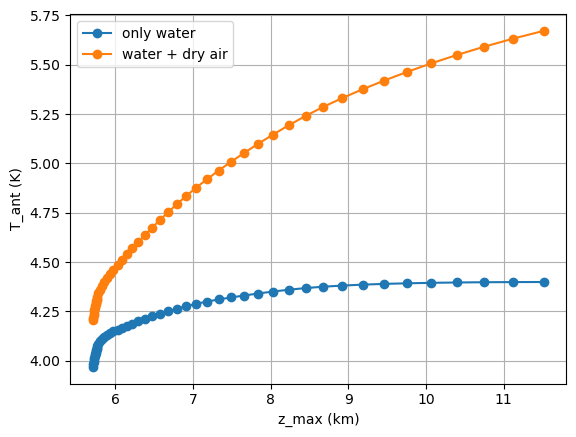

In [124]:
plt.figure()
plt.plot(z_max_list_rd/1000, T_list_rd- T_wo_w_list_rd, marker= 'o', label="only water")
plt.plot(z_max_list_rd/1000, T_list_rd, marker= 'o', label="water + dry air")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("T_ant (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

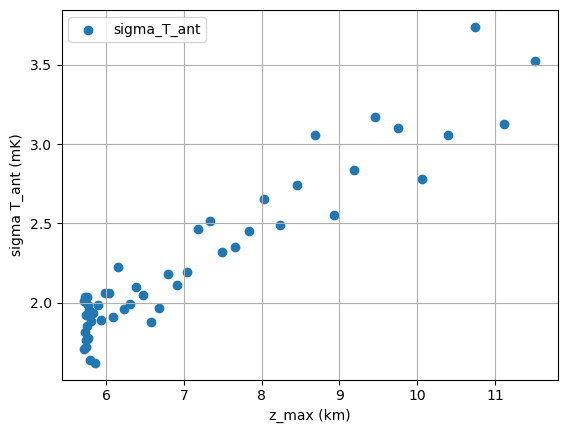

In [125]:
plt.figure()
plt.scatter(z_max_list_rd/1000, sigma_list_rd*1000, label="sigma_T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [122]:
print(sigma_list_rd.shape)

(25,)


In [78]:
Mcol = trapezoid(rho_water[1:], z_1) #kg/m2
print("Moment total de vapeur d'eau (kg/m2) :", Mcol)

z_moy = trapezoid(rho_water[1:]*z_1, z_1)/Mcol
print("Altitude moyenne de la colonne d'eau (m) :", z_moy)

var_vert = trapezoid(rho_water[1:]*(z_1 - z_moy)**2, z_1)/Mcol
std_vert = np.sqrt(var_vert)
print("Ecart type vertical de la colonne d'eau (m) :", std_vert)


Moment total de vapeur d'eau (kg/m2) : 0.8428249191824038
Altitude moyenne de la colonne d'eau (m) : 5493.700750766445
Ecart type vertical de la colonne d'eau (m) : 675.7645227407709


On veut savoir jusqu'à quelle altitude est-il pertinent d'intégrer pour mesurer tout T_ant et pas simplement du bruit

In [12]:
def max_relative_diff(ref, test, eps_denom=1e-6):
    ref = np.asarray(ref)
    test = np.asarray(test)
    denom = np.maximum(np.abs(ref), eps_denom)
    rel = np.abs(ref - test) / denom
    return np.max(rel)


In [128]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
#on va calculer la temperature d'antenne
pi = np.pi     
frequency = np.array([150e9]) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 10000, 200) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en 

epsilon    = 0.622 # rapport des masses molaires de l'eau et de l'air sec

elev = 90 #en deg

WVMR = epsilon * P_water / (Pressure - P_water) #kg/kg
WVMR = WVMR *1000 #g/kg

N_MC = 70

In [129]:
sigma_T, T_ant = predict_SNR_T(
            frequency=frequency,
            theta_b=theta_b,
            z=altitudes,
            WVMR=WVMR,
            elev=elev,
            T=Temperature,
            P=Pressure,
            N_MC=N_MC
        )

print(sigma_T, T_ant)

0.009478365660273519 [7.12166837]


In [25]:
# paramètres de tolérance (à ajuster selon ton cas physique)
eps_T = 0.01      # 1 % d'écart max sur T_ant
eps_sigma = 0.05  # 5 % d'écart max sur sigma_T

z_top = altitudes[-1]

candidate_indices = range(800, len(altitudes), 10)  # on évite les profils trop courts, et on échantillonne

z_max_opt = z_top
idx_opt = len(altitudes) - 1

# on garde aussi les séries cumulatives si tu veux inspecter
z_max_list = []
T_list = []
sigma_list = []

for idx in candidate_indices:
    z_trunc = altitudes[:idx+1]
    T_trunc = Temperature[:idx+1]
    P_trunc = Pressure[:idx+1]
    WVMR_trunc = WVMR[:idx+1]

    sigma_T_trunc, T_ant_trunc = predict_SNR_T(
        frequency=frequency,
        theta_b=theta_b,
        z=z_trunc,
        WVMR=WVMR_trunc,
        elev=elev,
        T=T_trunc,
        P=P_trunc,
        N_MC=N_MC
    )

    # erreurs relatives max sur toutes les fréquences
    err_T = max_relative_diff(T_ant, T_ant_trunc)
    err_sigma = max_relative_diff(sigma_T, sigma_T_trunc)

    z_max_list.append(z_trunc[-1])
    T_list.append(T_ant_trunc)
    sigma_list.append(sigma_T_trunc)

    

In [ ]:
T_list =

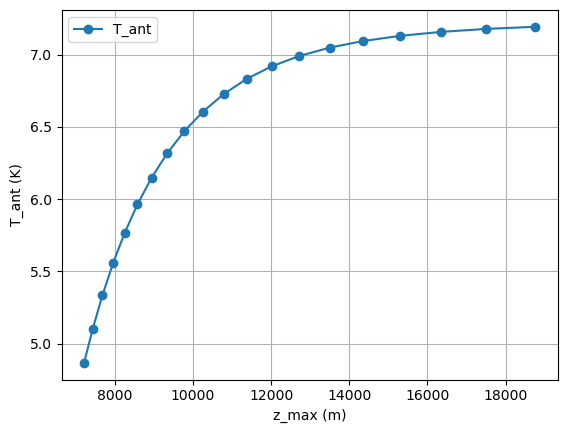

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(z_max_list, T_list, marker= 'o', label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (m)")
plt.ylabel("T_ant (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

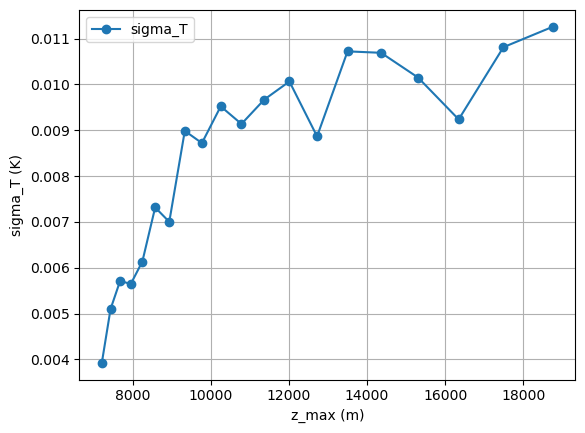

In [35]:
plt.figure()
#plt.plot(z_max_list, T_list, marker= 'o', label="T_ant")
plt.plot(z_max_list, sigma_list, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (m)")
plt.ylabel("sigma_T (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [23]:
print(T_ant_trunc)

[7.19236596]


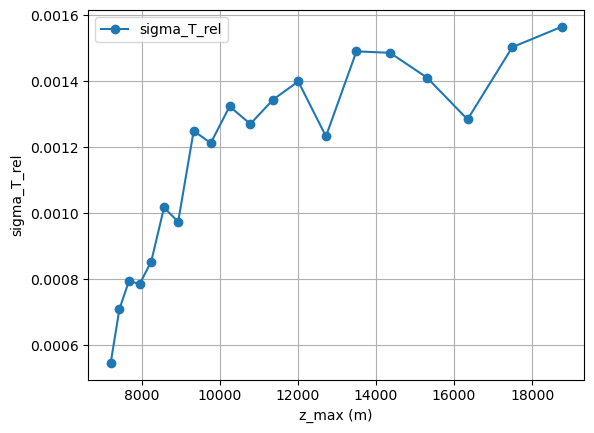

In [36]:
plt.figure()
#plt.plot(z_max_list, T_list, marker= 'o', label="T_ant")
plt.plot(z_max_list, sigma_list/T_ant_trunc, marker = 'o',label="sigma_T_rel")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (m)")
plt.ylabel("sigma_T_rel")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [67]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
#on va calculer la temperature d'antenne
pi = np.pi     
frequency = np.array([150e9]) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 25000, 1000) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

P_water_0 = P_water * 10e-15

In [51]:


T_ant_wo_water = Calcul_T_ant_1_el(frequency, theta_b, altitudes, Temperature, Pressure, P_water_0, elevation)

In [68]:


z_top = altitudes[-1]

candidate_indices = range(800, len(altitudes), 5)  # on évite les profils trop courts, et on échantillonne



# on garde aussi les séries cumulatives si tu veux inspecter
z_max_list = []
T_list = []
sigma_list = []

for idx in candidate_indices:
    z_trunc = altitudes[:idx+1]
    T_trunc = Temperature[:idx+1]
    P_trunc = Pressure[:idx+1]
    P_water_0_trunc = P_water_0[:idx+1]

    T_ant_wo_water_trunc = Calcul_T_ant_1_el(frequency, theta_b, z_trunc, T_trunc, P_trunc, P_water_0_trunc, elevation)

   

    z_max_list.append(z_trunc[-1])
    T_list.append(T_ant_wo_water_trunc)
    

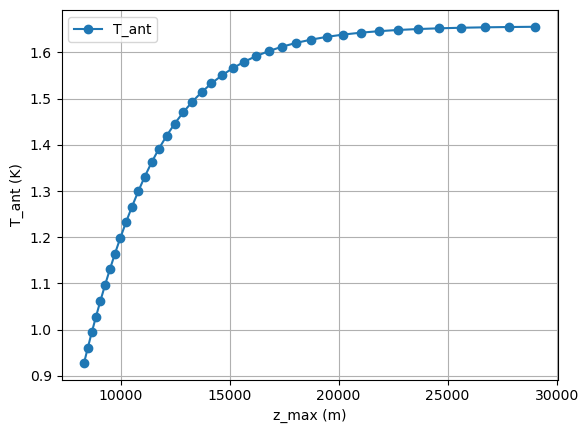

In [69]:
plt.figure()
plt.plot(z_max_list, T_list, marker= 'o', label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (m)")
plt.ylabel("T_ant (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

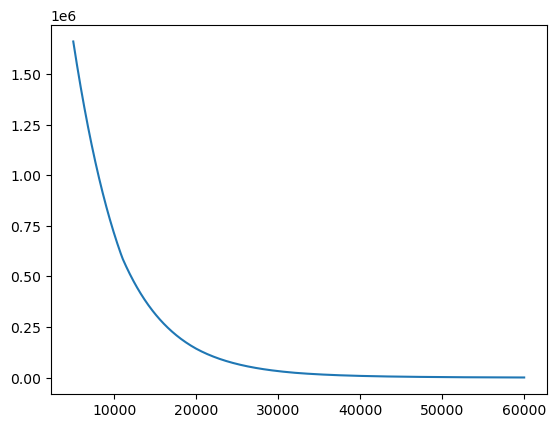

In [61]:
plt.plot (altitudes, Pressure * 100 / 8.314 *Temperature)
plt.show()

In [87]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
#on va calculer la temperature d'antenne
pi = np.pi     
frequency = np.array([150e9]) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 30000, 1000) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3

P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en 

P_water_0 = P_water * 10e-15




epsilon    = 0.622 # rapport des masses molaires de l'eau et de l'air sec

elev = 90 #en deg

WVMR = epsilon * P_water / (Pressure - P_water) #kg/kg
WVMR = WVMR *1000 #g/kg

N_MC = 150

In [88]:
# paramètres de tolérance (à ajuster selon ton cas physique)
eps_T = 0.01      # 1 % d'écart max sur T_ant
eps_sigma = 0.05  # 5 % d'écart max sur sigma_T

z_top = altitudes[-1]

candidate_indices = range(700, len(altitudes), 4)  # on évite les profils trop courts, et on échantillonne

z_max_opt = z_top
idx_opt = len(altitudes) - 1

# on garde aussi les séries cumulatives si tu veux inspecter
z_max_list = np.zeros(len(candidate_indices))
T_list = np.zeros(len(candidate_indices))
sigma_list = np.zeros(len(candidate_indices))
T_wo_w_list = np.zeros(len(candidate_indices))
i=0
for idx in candidate_indices:
    
    
    z_trunc = altitudes[:idx+1]
    T_trunc = Temperature[:idx+1]
    P_trunc = Pressure[:idx+1]
    WVMR_trunc = WVMR[:idx+1]
    P_water_0_trunc = P_water_0[:idx+1]

    sigma_T_trunc, T_ant_trunc = predict_SNR_T(
        frequency=frequency,
        theta_b=theta_b,
        z=z_trunc,
        WVMR=WVMR_trunc,
        elev=elev,
        T=T_trunc,
        P=P_trunc,
        N_MC=N_MC
    )
    T_ant_wo_w = Calcul_T_ant_1_el(frequency, theta_b, z_trunc, T_trunc, P_trunc, P_water_0_trunc, elevation)

    # erreurs relatives max sur toutes les fréquences
    #err_T = max_relative_diff(T_ant, T_ant_trunc)
    #err_sigma = max_relative_diff(sigma_T, sigma_T_trunc)

    z_max_list[i] = z_trunc[-1]
    T_list[i] = T_ant_trunc
    sigma_list[i] = sigma_T_trunc
    T_wo_w_list[i] = T_ant_wo_w
    i=i+1

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/2944020.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_list[i] = T_ant_trunc
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/2944020.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_wo_w_list[i] = T_ant_wo_w


In [89]:
T_water_list = T_list - T_wo_w_list
sigma_rel = sigma_list/T_list
sigma_rel_T_w = sigma_list/T_water_list

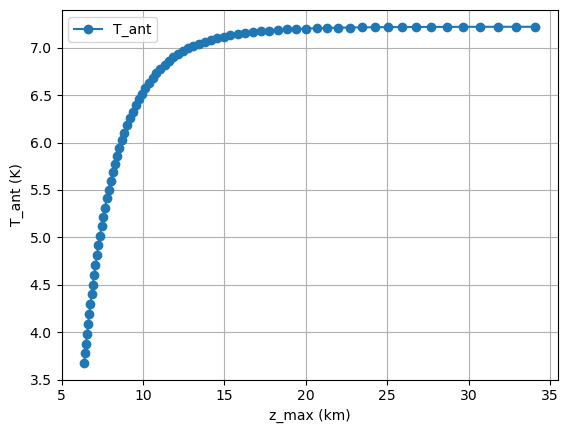

In [90]:
plt.figure()
plt.plot(z_max_list/1000, T_list, marker= 'o', label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("T_ant (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

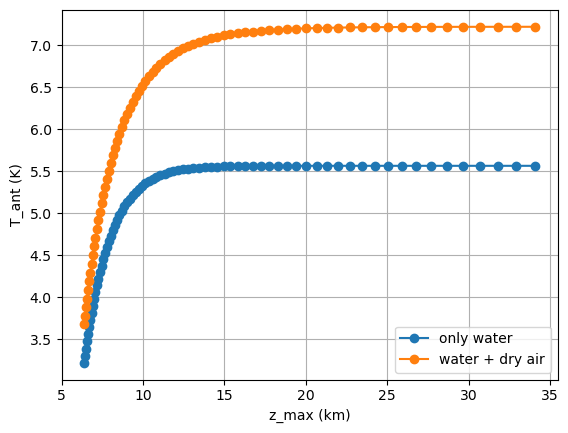

In [179]:
plt.figure()
plt.plot(z_max_list/1000, T_list- T_wo_w_list, marker= 'o', label="only water")
plt.plot(z_max_list/1000, T_list, marker= 'o', label="water + dry air")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("T_ant (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

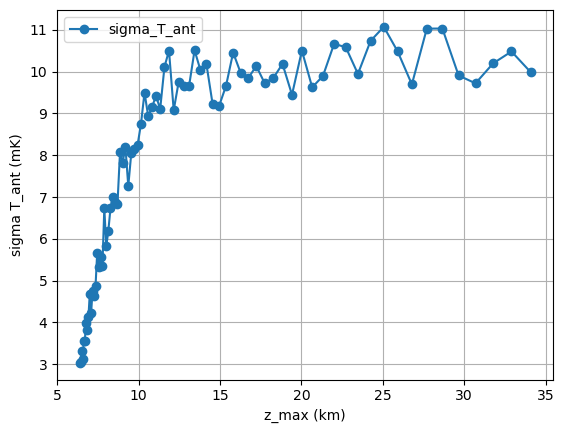

In [92]:
plt.figure()
plt.plot(z_max_list/1000, sigma_list*1000, marker= 'o', label="sigma_T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

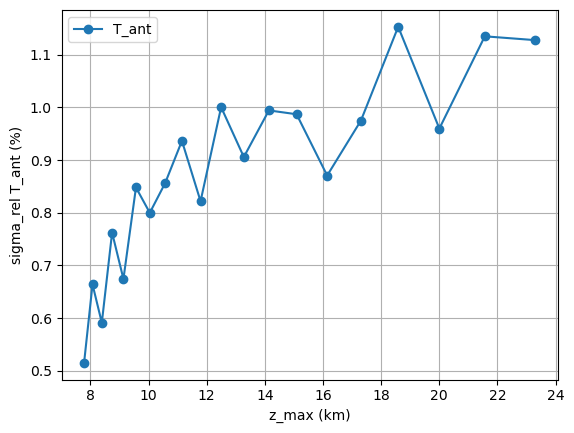

In [82]:
plt.figure()
plt.plot(z_max_list/1000, sigma_list*100, marker= 'o', label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma_rel T_ant (%)")
plt.legend()
plt.grid(True, which="both")
plt.show()

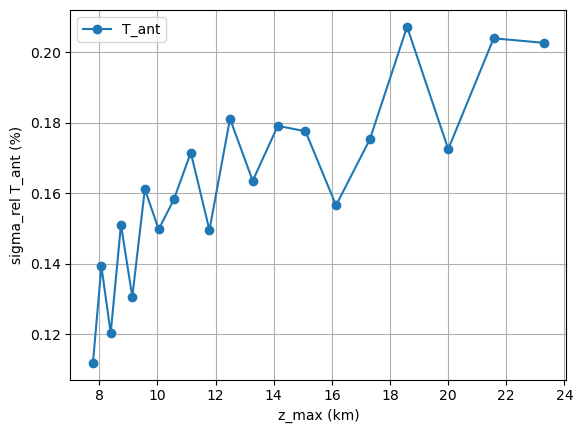

In [83]:
plt.figure()
plt.plot(z_max_list/1000, sigma_rel_T_w*100, marker= 'o', label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma_rel T_ant (%)")
plt.legend()
plt.grid(True, which="both")
plt.show()

On récupère les tableaux de valeurs pour les utiliser dans pic latex

In [180]:
%store z_max_list
%store T_list
%store sigma_list
%store T_wo_w_list

Stored 'z_max_list' (ndarray)
Stored 'T_list' (ndarray)
Stored 'sigma_list' (ndarray)
Stored 'T_wo_w_list' (ndarray)


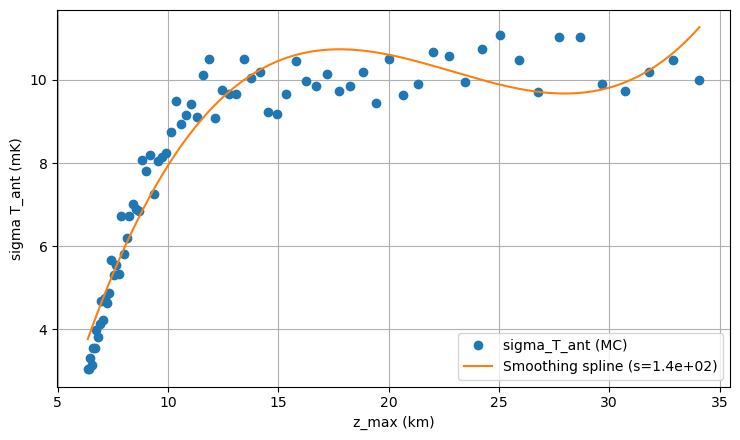

In [93]:
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq

# Données (déjà définies chez toi) :
# z_max_list en m, sigma_list en K (?)
x = np.asarray(z_max_list) / 1000.0       # km
y = np.asarray(sigma_list) * 1000.0       # mK

# 1) Sécurité : trier + dédoublonner en x
idx = np.argsort(x)
x, y = x[idx], y[idx]
mask = np.concatenate(([True], np.diff(x) > 0))
x, y = x[mask], y[mask]

# 2) Smoothing spline (k=3 par défaut). Choix de s via MAD (robuste).
mad = np.median(np.abs(y - np.median(y)))
sigma_est = 1.4826 * mad                 # ~écart-type robuste
s = 0.5 * len(x) * (sigma_est**2)        # facteur de lissage "doux" (ajuste si besoin)

spl = UnivariateSpline(x, y, k=3, s=s)

# 3) Évaluation dense + tracé
xx = np.linspace(x.min(), x.max(), 600)
yy = spl(xx)

plt.figure(figsize=(7.5, 4.5))
plt.plot(x, y, 'o', label="sigma_T_ant (MC)")
plt.plot(xx, yy, '-', label=f"Smoothing spline (s={s:.2g})")

plt.xlabel("z_max (km)")
plt.ylabel("sigma T_ant (mK)")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

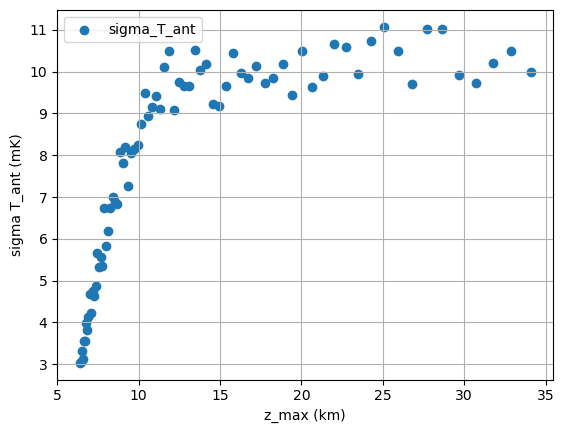

In [94]:
plt.figure()
plt.scatter(z_max_list/1000, sigma_list*1000, label="sigma_T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

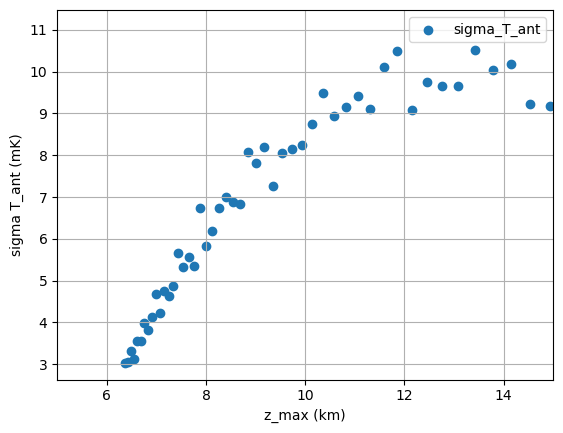

In [182]:
plt.figure()
plt.scatter(z_max_list/1000, sigma_list*1000, label="sigma_T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.xlim(5,15)
plt.ylabel("sigma T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [183]:
import numpy as np
from astropy import units as u
from scipy.integrate import cumulative_trapezoid  # Indispensable pour le calcul cumulatif

def Calcul_T_ant_cumulative(frequency, theta_b, altitudes, Temperature, Pressure, P_water, elevation, N=500):
    
    """
    Compute cumulative antenna temperature T_ant profile by integrating over altitude.

    Returns
    - T_ant_profile : 2D array (len(altitudes), len(frequency))
                      Value at index [i, :] corresponds to T_ant calculated from altitudes[0] to altitudes[i].
    """
    # --- 1. Définitions des géométries (Identique) ---
    pi = np.pi 
    thet = 90 - elevation
    thet_rad = thet * pi/180
    
    # Calcul de la masse d'air (m)
    m = 1/(np.cos(thet_rad) + 0.50572*(96.07995-thet)**(-1.6364))   
    
    # Conversions d'unités (Identique)
    # altitudes_km sert sans doute dans vos sous-fonctions externes
    altitudes_km = altitudes * u.m       
    altitudes_km = altitudes_km.to(u.km) 
    frequency_GHz = frequency*10**-9 * u.GHz

    # --- 2. Calcul des paramètres physiques (Identique) ---
    
    # Contribution de l'aire effective (supposée dépendre de z)
    # Renvoie un tableau (len(altitudes), len(frequency)) ou broadcastable
    C_alt = contribution_effective_area(frequency, theta_b, altitudes, elevation, N)
   
    # Calcul de l'atténuation spécifique alpha (Neper/m ou 1/m selon vos fonctions)
    alpha_specific = alpha_specific_function(altitudes, frequency, Temperature, Pressure, P_water)

    # Calcul de l'épaisseur optique cumulée depuis le sol (tau(z))
    # Note: Votre fonction 'optical_depth_emission' doit renvoyer tau(z) = intégrale de 0 à z de alpha.
    tau = optical_depth_emission(altitudes, alpha_specific)
    
    # --- 3. Définition de l'intégrande (Identique) ---
    # C'est le terme dTb/dz : Emission locale * Atténuation jusqu'au sol * Géométrie
    # Temperature[:, None] permet le broadcasting si frequency est un tableau
    C_tot = C_alt * alpha_specific * m * Temperature[:, None] * np.exp(-tau*m)
    
    # --- 4. Intégration Cumulative (CHANGEMENT ICI) ---
    
    # Au lieu de 'trapezoid' qui somme tout en un nombre, on utilise 'cumulative_trapezoid'
    # initial=0 garantit que le tableau de sortie a la même taille que 'altitudes' (T_ant(z=0) = 0)
    T_ant_profile = cumulative_trapezoid(C_tot, altitudes, axis=0, initial=0)
        
    return T_ant_profile

In [184]:
import numpy as np

def Monte_Carlo_T_ant_profile(f, theta_b, N, elev, MC_law, N_MC, WVMR, SNR, Temperature, Pressure, z):
    """
    Calcule :
    1. Le profil de sigma_T (écart-type dû aux fluctuations d'eau)
    2. Le profil de T_ant moyen (avec eau)
    3. Le profil de T_ant Dry (sans eau)
    
    Retourne 3 arrays de taille len(z).
    """
    
    # --- 1. Génération des perturbations (Eau) ---
    # WVMR_MC est une matrice (N_MC, len(z))
    WVMR_MC = MC_law(WVMR, N_MC, 1/SNR, rng=None)
    
    R_d_air = 287 # J/(kg*K)
    R_water = 462 # J/(kg*K)

    # Calcul de la Pression partielle d'eau pour tous les tirages
    rho_water_MC = Pressure*100*WVMR_MC/(1000*R_d_air*Temperature)*1/(1+R_water/R_d_air*WVMR_MC/1000) 
    P_water_MC = rho_water_MC*R_water*Temperature/100  # en hPa

    # --- 2. Calcul du Profil "Sans Eau" (Dry) ---
    # On le fait UNE SEULE FOIS ici pour gagner du temps.
    # On met une pression de vapeur d'eau quasi-nulle (1e-15 pour éviter des logs de zero potentiels)
    P_water_dry = np.full_like(Pressure, 1e-15)
    
    # On suppose que Calcul_T_ant_cumulative renvoie un array (len(z), 1) pour une seule fréq
    res_dry = Calcul_T_ant_cumulative(f, theta_b, z, Temperature, Pressure, P_water_dry, elev, N)
    
    # Gestion des dimensions si f est un scalaire
    if res_dry.ndim > 1 and res_dry.shape[1] == 1:
        T_ant_dry_profile = res_dry[:, 0]
    else:
        T_ant_dry_profile = res_dry

    # --- 3. Boucle Monte Carlo (Atmosphère Humide) ---
    
    Tant_MC_profiles = np.zeros((N_MC, len(z)))

    for i in range(N_MC):
        P_i = P_water_MC[i, :]  # Profil d'eau perturbé
        
        # Calcul cumulatif avec eau
        res = Calcul_T_ant_cumulative(f, theta_b, z, Temperature, Pressure, P_i, elev, N)
        
        # Stockage (flatten si nécessaire)
        Tant_MC_profiles[i, :] = res[:, 0] if res.ndim > 1 else res

    # --- 4. Statistiques ---
    
    # Ecart-type (Sigma_T)
    std_Tant_profile = np.std(Tant_MC_profiles, axis=0, ddof=1)
    
    # Moyenne (T_ant Total)
    mean_Tant_profile = np.mean(Tant_MC_profiles, axis=0)
    
    # Si vous préférez retourner le profil de référence (profil "moyen" sans bruit) au lieu de la moyenne des tirages :
    # Recalculer P_water_ref à partir du WVMR moyen et appeler Calcul_T_ant_cumulative une fois.
    # Ici, je retourne la moyenne des simulations MC.

    return std_Tant_profile, mean_Tant_profile, T_ant_dry_profile

In [187]:
pi = np.pi     
frequency = np.array([150e9]) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 30000, 1000) #m
altitudes = altitudes +4999 #m
N=500
altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en 

N_MC = 200


epsilon    = 0.622 # rapport des masses molaires de l'eau et de l'air sec

elev = 90 #en deg

WVMR = epsilon * P_water / (Pressure - P_water) #kg/kg
WVMR = WVMR *1000 #g/kg
#valeur de predict SNR sur le fichier de patrick 90°, 50cm mirror
A = 106533.049
c = 1.470303e-05

SNR_no_scale = calcul_snr (A, c, WVMR, altitudes, Pressure, Temperature, elev)

SNR = scale_snr_for_variable_bins(altitudes, SNR_no_scale, elev = 90, dz_ref=30.0) [0]

simu = Monte_Carlo_T_ant_profile(frequency, theta_b, N, elev, generate_Pwater_MC_lognormal, N_MC, WVMR, SNR, Temperature, Pressure, altitudes)

In [189]:
z_max = altitudes
sigma_T = simu[0]
T_ant = simu[1]
T_ant_wo_water = simu[2]

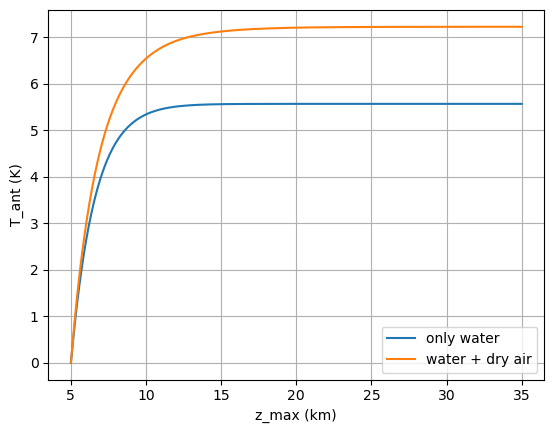

In [191]:
plt.figure()
plt.plot(z_max/1000, T_ant - T_ant_wo_water, label="only water")
plt.plot(z_max/1000, T_ant, label="water + dry air")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("T_ant (K)")
plt.legend()
plt.grid(True, which="both")
plt.show()

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/39110775.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


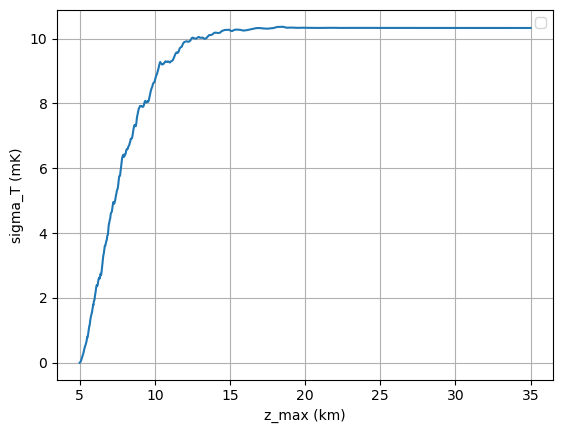

In [192]:
plt.figure()
plt.plot(z_max/1000, sigma_T*1000)

#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma_T (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3324959966.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(z_max/1000, sigma_T*100/(T_ant_wo_water))
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3324959966.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


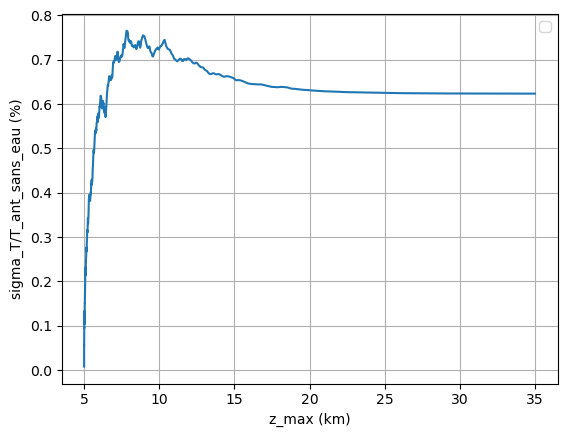

In [198]:
plt.figure()
plt.plot(z_max/1000, sigma_T*100/(T_ant_wo_water))

#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("z_max (km)")
plt.ylabel("sigma_T/T_ant_sans_eau (%)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [205]:
print(sigma_T)

[0.00000000e+00 1.24778194e-14 7.46446424e-14 2.65981886e-13
 7.17696781e-13 1.51976595e-12 2.78130695e-12 4.62730169e-12
 7.34143367e-12 1.12557791e-11 1.66872162e-11 2.24543999e-11
 2.95176111e-11 3.87807637e-11 5.23311465e-11 6.94498624e-11
 8.53620380e-11 9.73413404e-11 1.08640951e-10 1.26248832e-10
 1.54034828e-10 1.82105140e-10 2.14462798e-10 2.53096029e-10
 3.03012495e-10 3.64146543e-10 4.17992485e-10 4.81171958e-10
 5.69209582e-10 6.49668330e-10 7.24251322e-10 8.10661201e-10
 8.98853480e-10 9.88129980e-10 1.11917416e-09 1.23961806e-09
 1.37158789e-09 1.46479007e-09 1.57995056e-09 1.78558356e-09
 1.99296466e-09 2.19085394e-09 2.43297084e-09 2.68599830e-09
 2.90234717e-09 3.07852474e-09 3.22456897e-09 3.40863685e-09
 3.76759584e-09 4.10963553e-09 4.30703994e-09 4.56133663e-09
 4.82769720e-09 5.24078689e-09 5.63790300e-09 6.12844778e-09
 6.73262453e-09 7.17913400e-09 7.60145070e-09 8.32910740e-09
 9.02017136e-09 9.45269259e-09 9.64191898e-09 1.00655990e-08
 1.07868715e-08 1.158493

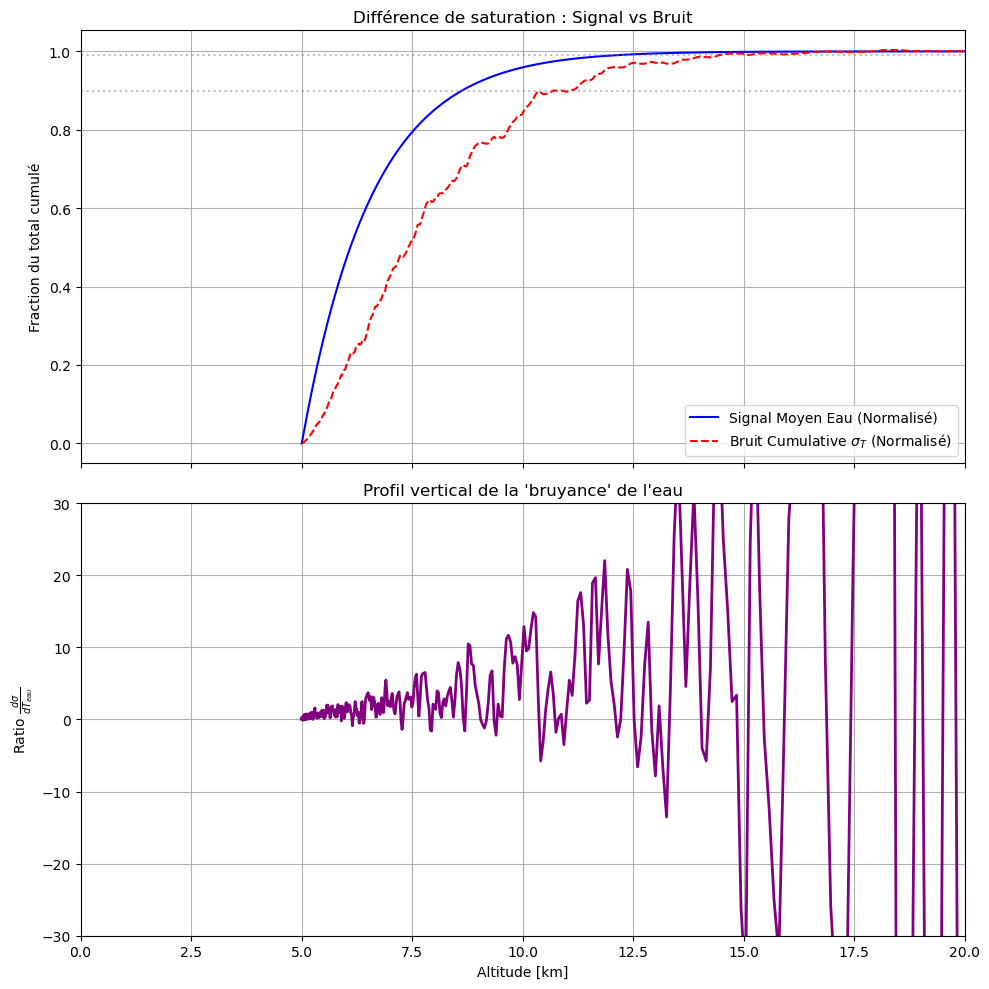

In [204]:
T_water = T_ant - T_ant_wo_water

# 2. Calculer les dérivées
grad_sigma = np.gradient(sigma_T, altitudes)
grad_T_water = np.gradient(T_water, altitudes)

# Petit epsilon pour division par zero
grad_T_water[grad_T_water < 1e-12] = 1e-12 

# 3. Le Ratio Intrinsèque (Combien de bruit par Kelvin d'eau ajouté)
ratio_intrinsic = grad_sigma / grad_T_water

# --- Visualisation ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Plot 1 : Comparaison des saturations (Normalisées à 1)
# C'est ce qui montrera visuellement votre observation (99% vs 90%)
ax1.plot(altitudes/1000, T_water / T_water[-1], label=r'Signal Moyen Eau (Normalisé)', color='blue')
ax1.plot(altitudes/1000, sigma_T/ sigma_T[-1], label=r'Bruit Cumulative $\sigma_T$ (Normalisé)', color='red', linestyle='--')

# Lignes guides
ax1.axhline(0.99, color='gray', linestyle=':', alpha=0.5)
ax1.axhline(0.90, color='gray', linestyle=':', alpha=0.5)
ax1.set_ylabel('Fraction du total cumulé')
ax1.set_title("Différence de saturation : Signal vs Bruit")
ax1.legend()
ax1.grid(True)

# Plot 2 : Le Ratio Intrinsèque
ax2.plot(altitudes/1000, ratio_intrinsic*1000, color='purple', linewidth=2)
ax2.set_ylabel(r'Ratio $\frac{d\sigma}{dT_{eau}}$')
ax2.set_xlabel('Altitude [km]')
ax2.set_title("Profil vertical de la 'bruyance' de l'eau")
ax2.grid(True)

# Zoom sur la zone intéressante (ex: 0 à 15km) car après y'a plus d'eau
ax2.set_xlim(0, 20) 
ax2.set_ylim(-30, 30) 

plt.tight_layout()
plt.show()

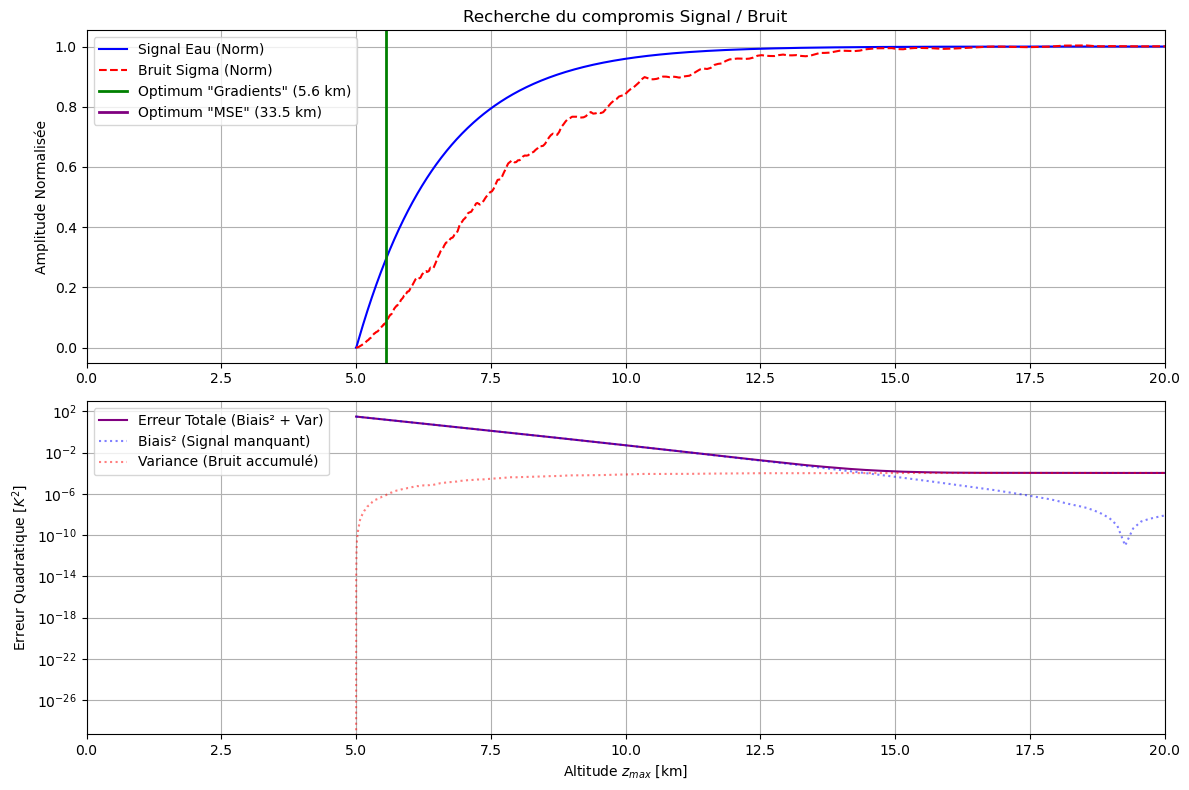

--- RÉSULTATS D'OPTIMISATION ---
1. Méthode Gradients : z = 5564 m
   Capture 29.8% du signal pour 8.7% du bruit max.
2. Méthode MSE (Total Error) : z = 33490 m


In [207]:
import numpy as np
import matplotlib.pyplot as plt

# On suppose que vous avez :
# altitudes, sigma_prof, T_mean_prof, T_dry_prof
# Calcul du profil d'eau isolé
T_water_prof = T_water
sigma_prof = sigma_T


# --- Méthode 1 : Croisement des gradients normalisés ---
# Normalisation (0 à 1)
T_norm = T_water_prof / T_water_prof[-1]
sigma_norm = sigma_prof / sigma_prof[-1]

# Gradients
grad_T_norm = np.gradient(T_norm, altitudes)
grad_sigma_norm = np.gradient(sigma_norm, altitudes)

# On cherche l'indice où le gradient de sigma devient supérieur au gradient de T
# (On ignore les tout premiers points souvent instables)
start_idx = 10 
# Condition : grad_T < grad_sigma
mask_crossover = (grad_T_norm[start_idx:] < grad_sigma_norm[start_idx:])
if np.any(mask_crossover):
    idx_opt_1 = np.argmax(mask_crossover) + start_idx
else:
    idx_opt_1 = len(altitudes) - 1 # On va jusqu'au bout si ça ne croise jamais

z_opt_1 = altitudes[idx_opt_1]


# --- Méthode 3 : Minimisation MSE (Biais vs Variance) ---
# Biais = La vraie valeur totale (estimée par la fin du profil) - valeur actuelle
bias_squared = (T_water_prof[-1] - T_water_prof)**2
variance = sigma_prof**2
MSE = bias_squared + variance

idx_opt_3 = np.argmin(MSE)
z_opt_3 = altitudes[idx_opt_3]


# --- Visualisation des décisions ---
plt.figure(figsize=(12, 8))

# Plot Principal : Courbes normalisées
plt.subplot(2, 1, 1)
plt.plot(altitudes/1000, T_norm, label='Signal Eau (Norm)', color='blue')
plt.plot(altitudes/1000, sigma_norm, label='Bruit Sigma (Norm)', color='red', linestyle='--')

# Affichage des points optimaux
plt.axvline(z_opt_1/1000, color='green', linestyle='-', linewidth=2, 
            label=f'Optimum "Gradients" ({z_opt_1/1000:.1f} km)')
plt.axvline(z_opt_3/1000, color='purple', linestyle='-', linewidth=2, 
            label=f'Optimum "MSE" ({z_opt_3/1000:.1f} km)')

plt.title("Recherche du compromis Signal / Bruit")
plt.ylabel("Amplitude Normalisée")
plt.legend()
plt.grid(True)
plt.xlim(0, 20) # Zoom sur la zone utile

# Plot Secondaire : La fonction de coût MSE
plt.subplot(2, 1, 2)
plt.plot(altitudes/1000, MSE, color='purple', label='Erreur Totale (Biais² + Var)')
plt.plot(altitudes/1000, bias_squared, color='blue', linestyle=':', alpha=0.5, label='Biais² (Signal manquant)')
plt.plot(altitudes/1000, variance, color='red', linestyle=':', alpha=0.5, label='Variance (Bruit accumulé)')

plt.axvline(z_opt_3/1000, color='purple', linestyle='--')
plt.ylabel(r"Erreur Quadratique [$K^2$]")
plt.xlabel("Altitude $z_{max}$ [km]")
plt.yscale('log') # Log scale souvent nécessaire pour voir le creux
plt.legend()
plt.grid(True)
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

print(f"--- RÉSULTATS D'OPTIMISATION ---")
print(f"1. Méthode Gradients : z = {z_opt_1:.0f} m")
print(f"   Capture {T_norm[idx_opt_1]*100:.1f}% du signal pour {sigma_norm[idx_opt_1]*100:.1f}% du bruit max.")
print(f"2. Méthode MSE (Total Error) : z = {z_opt_3:.0f} m")

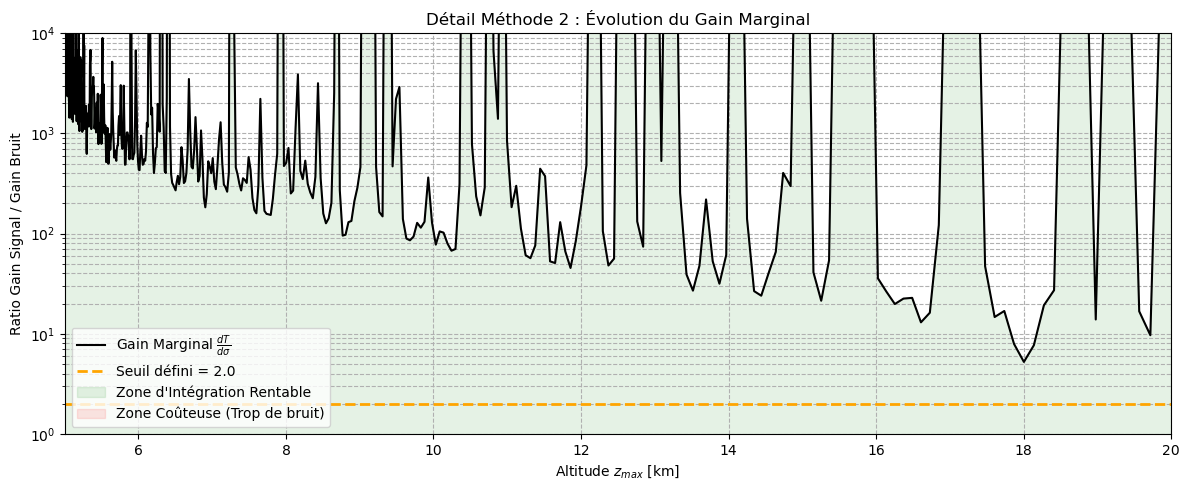

--- RÉSULTATS ---
M1 (Gradients croisés) : z = 5564 m
M2 (Gain Marginal > 2.0) : z = 20985 m
M3 (Erreur Min MSE)    : z = 33490 m


In [212]:
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Préparation des données ---


# Calcul des gradients (dérivées locales par rapport à z)
dz = np.gradient(altitudes)
grad_T_water = np.gradient(T_water_prof, altitudes)
grad_sigma = np.gradient(sigma_prof, altitudes)

# Sécurité numérique pour éviter la division par zéro
grad_sigma[grad_sigma < 1e-12] = 1e-12
grad_T_water[grad_T_water < 1e-12] = 1e-12

# ==============================================================================
# METHODE 2 : Coût Marginal (Marginal SNR)
# "Combien de signal je gagne pour 1 unité de bruit ajoutée ?"
# ==============================================================================

# Calcul du ratio instantané
# marginal_gain(z) = (dT/dz) / (dSigma/dz)
marginal_gain = grad_T_water / grad_sigma

# Définition du SEUIL (C'est le paramètre à régler)
# threshold = 2.0 signifie : "Je m'arrête quand je gagne moins de 2K de signal pour 1K de bruit."
# threshold = 1.0 est le point d'équilibre strict.
threshold_m2 = 2.0 

# Recherche de l'index où le gain passe sous le seuil
# On ignore les premiers points (ex: < 500m) qui peuvent être instables
start_idx = 20 

# On cherche le premier point après start_idx où le gain < seuil
mask_below = (marginal_gain[start_idx:] < threshold_m2)

if np.any(mask_below):
    # On ajoute start_idx car argmax renvoie l'index relatif au slice
    idx_opt_2 = np.argmax(mask_below) + start_idx
else:
    idx_opt_2 = len(altitudes) - 1

z_opt_2 = altitudes[idx_opt_2]

# --- Plot 2 : Focus sur la METHODE 2 (Gain Marginal) ---

plt.figure(figsize=(12,5))
plt.plot(altitudes/1000, marginal_gain, color='black', linewidth=1.5, label=r'Gain Marginal $\frac{dT}{d\sigma}$')
plt.axhline(threshold_m2, color='orange', linestyle='--', linewidth=2, label=f'Seuil défini = {threshold_m2}')

# Zone de décision
plt.fill_between(altitudes/1000, 0, marginal_gain, where=(marginal_gain > threshold_m2), 
                 color='green', alpha=0.1, label="Zone d'Intégration Rentable")
plt.fill_between(altitudes/1000, 0, marginal_gain, where=(marginal_gain <= threshold_m2), 
                 color='red', alpha=0.1, label="Zone Coûteuse (Trop de bruit)")

plt.xlabel("Altitude $z_{max}$ [km]")
plt.ylabel(r"Ratio Gain Signal / Gain Bruit")
plt.yscale('log') # Log scale recommandé car ce ratio varie énormément
plt.ylim(1, 10000) # Bornes pour lisibilité
plt.xlim(5, 20)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.title("Détail Méthode 2 : Évolution du Gain Marginal")

plt.tight_layout()
plt.show()

print(f"--- RÉSULTATS ---")
print(f"M1 (Gradients croisés) : z = {z_opt_1:.0f} m")
print(f"M2 (Gain Marginal > {threshold_m2}) : z = {z_opt_2:.0f} m")
print(f"M3 (Erreur Min MSE)    : z = {z_opt_3:.0f} m")

Altitude de coupure (90% eau) : 9487.4 m
Lancement de la simulation pour 20 points...


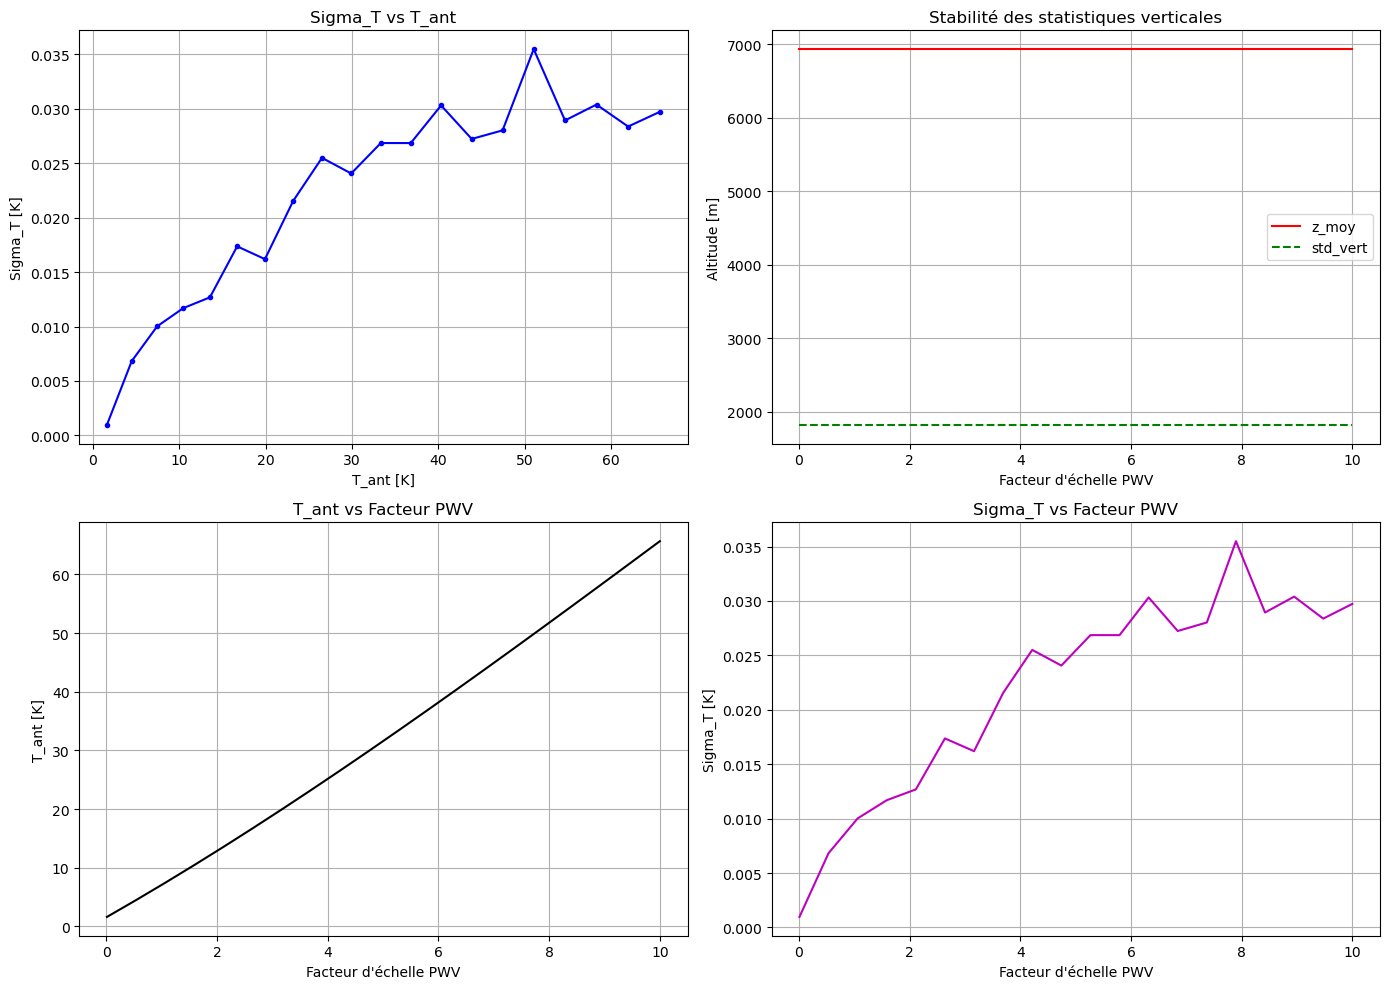

Moyenne z_moy sur la boucle : 6932.16 m
Moyenne std_vert sur la boucle : 1821.27 m


In [133]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid  # Pour l'intégration numérique
import matplotlib.pyplot as plt


# =============================================================================
# 2. INITIALISATION ET MAILLAGE HAUTE RÉSOLUTION (z_1)
# =============================================================================

# Paramètres généraux
pi = np.pi     
frequency = np.array([150e9]) # Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 90
N_MC = 70
epsilon = 0.622
R_water = 461.5 # J/kg/K

# -- 2a. Création de la grille fine linéaire (z_1) --
# On prend large (ex: 2000 points) pour avoir une bonne précision sur z_moy et z_break
altitudes_hr = np.linspace(5000, 15000, 2000) # m
z_1 = altitudes_hr
z_1_km = (z_1 * u.m).to(u.km)

# -- 2b. Récupération des profils Pycraf sur la grille fine --
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        # K
P_1 = profile[1].value        # hPa
rho_water_1_base = profile[2].value # g/m^3 (Profil standard de base)
P_water_1_base = profile[3].value   # hPa (Profil standard de base)

# =============================================================================
# 3. CRÉATION DE LA GRILLE RÉDUITE OPTIMISÉE (zg)
# =============================================================================

N_Z = 200
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
gamma = 2
Z_FLOOR = 5000

# Calcul du z_break sur le profil standard (la forme ne change pas avec le scaling)
z_break = calcul_z_percentile_wvc(z_1, rho_water_1_base, 90)
print(f"Altitude de coupure (90% eau) : {z_break:.1f} m")

zmin = max(float(np.nanmin(z_1)), Z_FLOOR)
zmax = float(np.nanmax(z_1))

# Génération du maillage réduit
zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)

# =============================================================================
# 4. BOUCLE DE CALCUL AVEC SCALING PWV
# =============================================================================

# Facteurs d'échelle PWV
x_scale = np.linspace(0.01, 10, 20)

# Tableaux pour stocker les résultats
sigma_T_results = np.zeros_like(x_scale)
T_ant_results = np.zeros_like(x_scale)
z_moy_results = np.zeros_like(x_scale)
std_vert_results = np.zeros_like(x_scale)
PWV_results = np.zeros_like(x_scale) # Pour vérification

print(f"Lancement de la simulation pour {len(x_scale)} points...")

for i, val in enumerate(x_scale):
    
    # --- A. Mise à l'échelle sur la grille HAUTE RÉSOLUTION (z_1) ---
    # On travaille sur z_1 pour calculer les intégrales (z_moy, std) avec précision
    
    P_water_1_scaled = P_water_1_base * val
    
    # Recalcul de rho_water sur z_1 (Loi des gaz parfaits pour la vapeur d'eau)
    # rho = P / (R * T). Attention aux unités : P en Pascal pour formule SI
    # P_water_1_scaled est en hPa -> * 100 pour Pa
    # T_1 en K
    # R_water = 461.5 J/kg/K
    # Resultat en kg/m3 -> * 1000 pour g/m3
    rho_water_1_scaled = (P_water_1_scaled * 100) / (R_water * T_1) * 1000 # g/m^3
    
    # --- B. Calcul des statistiques verticales sur z_1 ---
    
    # Calcul du PWV total (intégrale de rho selon z) en g/m^2 ou mm
    current_PWV = trapezoid(rho_water_1_scaled, z_1)
    
    # Altitude moyenne (z_moy)
    # Intégrale (rho * z) / PWV
    z_moy = trapezoid(rho_water_1_scaled * z_1, z_1) / current_PWV
    
    # Variance et Ecart-type vertical
    var_vert = trapezoid(rho_water_1_scaled * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    # Stockage des stats
    z_moy_results[i] = z_moy
    std_vert_results[i] = std_vert
    PWV_results[i] = current_PWV / 1000 # Conversion souvent utile (kg/m^2) si rho en g
    
    # --- C. Interpolation vers la grille RÉDUITE (zg) pour Monte Carlo ---
    
    # Interpolation des champs scalés depuis z_1 vers zg
    T_g = np.interp(zg, z_1, T_1)
    P_g = np.interp(zg, z_1, P_1)
    P_water_g = np.interp(zg, z_1, P_water_1_scaled)
    
    # Recalcul du WVMR sur la grille réduite
    # WVMR = epsilon * P_w / (P_dry) = epsilon * P_w / (P_tot - P_w)
    denom = P_g - P_water_g
    denom[denom <= 0] = 1e-6 # Sécurité numérique
    
    WVMR_g = epsilon * P_water_g / denom * 1000 # g/kg
    
    # --- D. Appel de la fonction de prédiction ---
    
    # On passe les vecteurs réduits (_g)
    sig, temp = predict_SNR_T(
        frequency=frequency,
        theta_b=theta_b,
        z=zg,           # Grille réduite
        WVMR=WVMR_g,    # Profil interpolé
        elev=elev,
        T=T_g,
        P=P_g,
        N_MC=N_MC
    )
    
    # Moyenne si la fonction retourne un array
    sigma_T_results[i] = np.mean(sig)
    T_ant_results[i] = np.mean(temp)

# =============================================================================
# 5. VISUALISATION
# =============================================================================

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 : Sigma_T vs T_ant
ax[0, 0].plot(T_ant_results, sigma_T_results, 'b.-')
ax[0, 0].set_xlabel("T_ant [K]")
ax[0, 0].set_ylabel("Sigma_T [K]")
ax[0, 0].set_title("Sigma_T vs T_ant")
ax[0, 0].grid(True)

# Plot 2 : Évolution des stats verticales avec le scaling (devrait être constant si pur scaling linéaire)
# Note: Si on scale P_water linéairement, z_moy et std_vert doivent être constants !
# C'est un bon moyen de vérifier que le calcul est cohérent.
ax[0, 1].plot(x_scale, z_moy_results, 'r-', label='z_moy')
ax[0, 1].plot(x_scale, std_vert_results, 'g--', label='std_vert')
ax[0, 1].set_xlabel("Facteur d'échelle PWV")
ax[0, 1].set_ylabel("Altitude [m]")
ax[0, 1].set_title("Stabilité des statistiques verticales")
ax[0, 1].legend()
ax[0, 1].grid(True)

# Plot 3 : T_ant vs PWV (ou facteur d'échelle)
ax[1, 0].plot(x_scale, T_ant_results, 'k-')
ax[1, 0].set_xlabel("Facteur d'échelle PWV")
ax[1, 0].set_ylabel("T_ant [K]")
ax[1, 0].set_title("T_ant vs Facteur PWV")
ax[1, 0].grid(True)

# Plot 4 : Sigma_T vs PWV
ax[1, 1].plot(x_scale, sigma_T_results, 'm-')
ax[1, 1].set_xlabel("Facteur d'échelle PWV")
ax[1, 1].set_ylabel("Sigma_T [K]")
ax[1, 1].set_title("Sigma_T vs Facteur PWV")
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Affichage de quelques valeurs stats moyennes pour vérification
print(f"Moyenne z_moy sur la boucle : {np.mean(z_moy_results):.2f} m")
print(f"Moyenne std_vert sur la boucle : {np.mean(std_vert_results):.2f} m")

In [134]:
print(PWV_results)

[1.22289314e-02 6.55213270e-01 1.29819761e+00 1.94118195e+00
 2.58416629e+00 3.22715063e+00 3.87013497e+00 4.51311931e+00
 5.15610364e+00 5.79908798e+00 6.44207232e+00 7.08505666e+00
 7.72804100e+00 8.37102534e+00 9.01400968e+00 9.65699402e+00
 1.02999784e+01 1.09429627e+01 1.15859470e+01 1.22289314e+01]


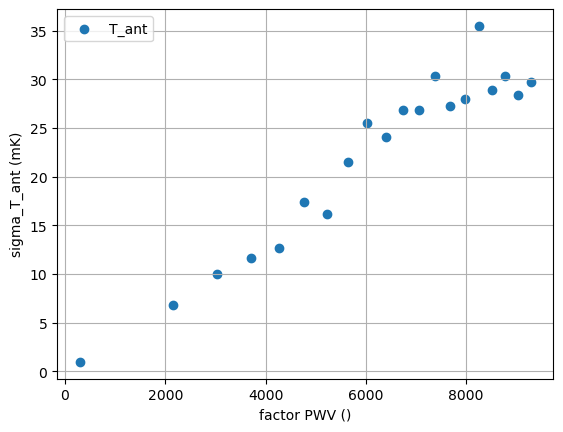

In [137]:
factor = np.sqrt(PWV_results*(std_vert_results**2+ (z_moy_results-5000)**2))

plt.figure()
plt.scatter(factor, sigma_T_results*1000, label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("factor PWV ()")
plt.ylabel("sigma_T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()


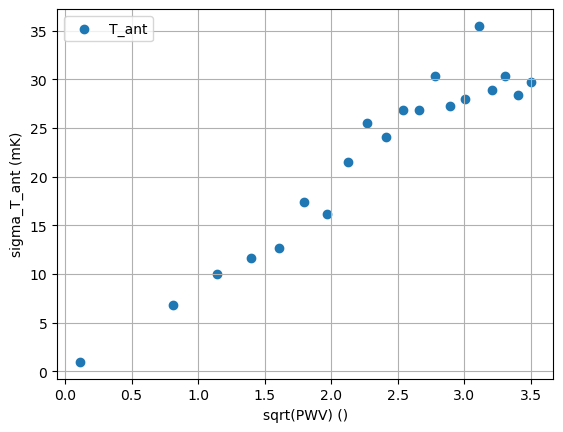

In [213]:
plt.figure()
plt.scatter(np.sqrt(PWV_results), sigma_T_results*1000, label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("sqrt(PWV) ()")
plt.ylabel("sigma_T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

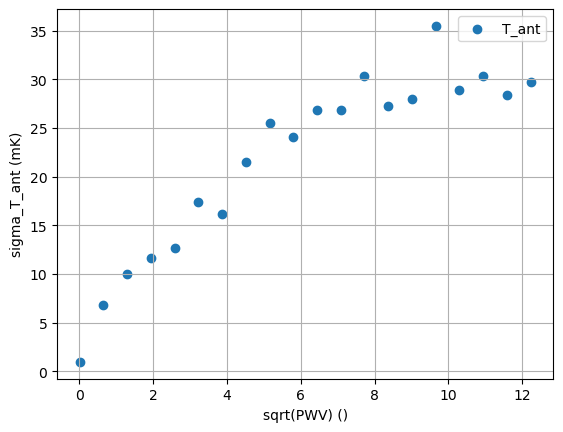

In [214]:
plt.figure()
plt.scatter(PWV_results, sigma_T_results*1000, label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("sqrt(PWV) ()")
plt.ylabel("sigma_T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [215]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# =============================================================================
# 1. FONCTIONS ET INITIALISATION
# =============================================================================


def add_gaussian_layer(z, profile_base, center_alt, width, amplitude):
    """
    Ajoute une couche gaussienne au profil de base.
    z          : vecteur altitude (m)
    profile_base: profil P_water original (hPa)
    center_alt : altitude du centre de la couche (m)
    width      : écart-type (épaisseur) de la couche (m)
    amplitude  : intensité max de la couche ajoutée (hPa)
    """
    # Formule de la gaussienne
    gaussian = amplitude * np.exp(-0.5 * ((z - center_alt) / width)**2)
    
    # On ajoute au profil existant
    return profile_base + gaussian

# --- Paramètres fixes ---
pi = np.pi     
frequency = np.array([150e9]) 
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 90
N_MC = 200
epsilon = 0.622
R_water = 461.5
N_Z = 150
Z_obs = 5000 # Altitude de l'observateur (pour votre formule)

Tc = T_1 - 273.15
P_sat = 6.112 * np.exp((17.67 * Tc) / (Tc + 243.5))

# --- Grille Haute Résolution (z_1) pour la physique ---
z_1 = np.linspace(5000, 15000, 2000) # m
z_1_km = (z_1 * u.m).to(u.km)

# Profils de base Pycraf
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value
P_1 = profile[1].value
P_water_base = profile[3].value # Profil de forme de base

# --- Grille Réduite (zg) pour le calcul Monte Carlo (fixe mais conservatrice) ---
# On prend un z_break un peu plus haut (4000 au lieu de 2000) pour accommoder les profils étirés
z_break_fixe = 9000 
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
zg = hybrid_lin_geom(5000, z_break_fixe, 20000, N_lin=N_lin, N_geom=N_geom, gamma=2)

# Interpolation du T et P sur la grille réduite (supposés constants, seule l'eau bouge)
T_g = np.interp(zg, z_1, T_1)
P_g = np.interp(zg, z_1, P_1)


# =============================================================================
# 2. BOUCLE DE GÉNÉRATION ALÉATOIRE
# =============================================================================

N_scenarios = 150 # Nombre de points dans le plot

# Tableaux de résultats
sigma_T_res = np.zeros(N_scenarios)
T_ant_res = np.zeros(N_scenarios)
PWV_res = np.zeros(N_scenarios)
z_moy_res = np.zeros(N_scenarios)
std_vert_res = np.zeros(N_scenarios)

print(f"Génération de {N_scenarios} atmosphères modifiées...")

for i in range(N_scenarios):
    
    # --- A. Tirage des paramètres de la couche (Perturbation) ---
    
    # 1. Altitude de la couche (ex: entre 5000m et 12000m)
    z_layer = np.random.uniform(5500, 7000)
    
    # 2. Largeur de la couche (sigma) (ex: couche fine de 200m ou épaisse de 2km)
    width_layer = np.random.uniform(200, 1000)
    
    # 3. Amplitude de la couche (en hPa)
    # Attention : À 5km, P_water est faible (~1-2 hPa). 
    # On tire une amplitude qui peut être significative par rapport au profil de base.
    amp_layer = np.random.uniform(0.0, 2.5) 
    
    # 4. (Optionnel) Scaling du bruit de fond Pycraf (pour varier aussi ce qui n'est pas la couche)
    bg_scale = np.random.uniform(0.2, 1.0)
    
    # --- B. Création du profil P_water modifié sur z_1 ---
    
    # On prend le profil de base scalé
    P_base_scaled = P_water_base * bg_scale
    
    # On ajoute la gaussienne
    P_water_final = add_gaussian_layer(z_1, P_base_scaled, z_layer, width_layer, amp_layer)
    

    # Dans la boucle, après avoir calculé P_water_final :
    P_water_final = np.minimum(P_water_final, P_sat)
    
    # Calcul de rho_water (loi gaz parfaits) pour avoir la "vraie" distribution de masse
    # C'est important car z_moy dépend de la masse (rho), pas de la pression (P)
    rho_water_scaled = (P_water_final * 100) / (R_water * T_1) * 1000 # g/m3
    
    
    # --- C. Calcul des statistiques "Vérité Terrain" sur z_1 ---
    
    current_PWV = trapezoid(rho_water_scaled, z_1)
    
    # Sécurité pour éviter division par zero si PWV très faible
    if current_PWV < 1e-6:
        current_PWV = 1e-6
        
    z_moy = trapezoid(rho_water_scaled * z_1, z_1) / current_PWV
    var_vert = trapezoid(rho_water_scaled * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    # Stockage
    PWV_res[i] = current_PWV # g/m^2 ou mm
    z_moy_res[i] = z_moy
    std_vert_res[i] = std_vert
    
    # --- D. Interpolation vers grille réduite zg et Calcul T_ant/Sigma ---
    
    P_water_g = np.interp(zg, z_1, P_water_final)
    
    # Calcul WVMR sur grille réduite
    denom = P_g - P_water_g
    denom[denom <= 0] = 1e-6
    WVMR_g = epsilon * P_water_g / denom * 1000 # g/kg
    
    sig, temp = predict_SNR_T(
        frequency=frequency,
        theta_b=theta_b,
        z=zg,
        WVMR=WVMR_g,
        elev=elev,
        T=T_g,
        P=P_g,
        N_MC=N_MC
    )
    
    sigma_T_res[i] = np.mean(sig)
    T_ant_res[i] = np.mean(temp)



Génération de 150 atmosphères modifiées...


/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/1553500648.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


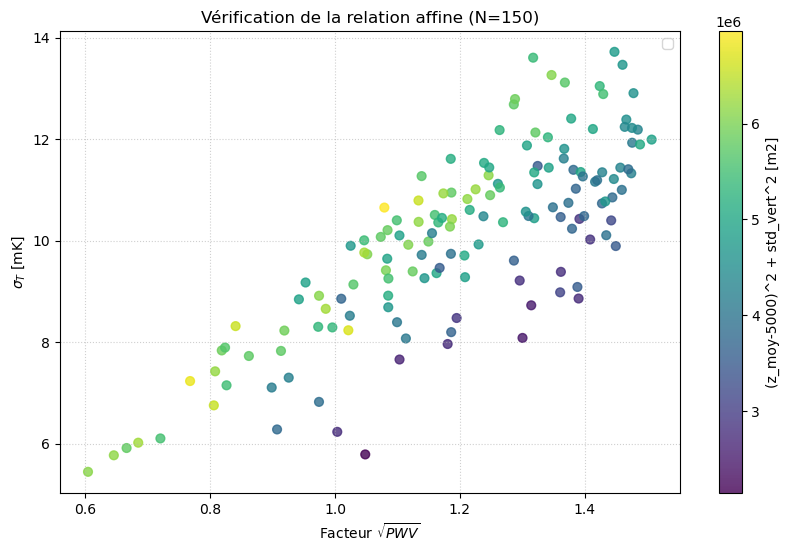

Variation z_moy : 5982 m à 6945 m
Variation std_vert : 1056 m à 1807 m


In [216]:
# =============================================================================
# 3. VERIFICATION DE LA RELATION AFFINE
# =============================================================================

# Votre facteur proposé
# factor = sqrt( PWV * ( std^2 + (z_moy - z_obs)^2 ) )
# Note : z_obs est ici 5000m (le bas du modèle)

dist_term = (z_moy_res - Z_obs)**2
geom_factor = std_vert_res**2 + dist_term

# Le facteur X pour le plot
X_factor = np.sqrt(PWV_res * geom_factor)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(np.sqrt(PWV_res/1000), sigma_T_res*1000, c=((z_moy_res-Z_obs)**2+std_vert_res**2), cmap='viridis', s=40, alpha=0.8)
plt.colorbar(label='(z_moy-5000)^2 + std_vert^2 [m2]')

# Régression linéaire pour voir si c'est affine
coeffs = np.polyfit(X_factor, sigma_T_res, 1)
poly = np.poly1d(coeffs)
#plt.plot(X_factor, poly(X_factor), 'r--', alpha=0.5, label=f'Fit: y={coeffs[0]:.2e}x + {coeffs[1]:.2e}')

plt.title(f"Vérification de la relation affine (N={N_scenarios})")
plt.xlabel(r"Facteur $\sqrt{PWV}$")
plt.ylabel(r"$\sigma_T$ [mK]")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Affichage des plages de variations pour confirmer la diversité
print(f"Variation z_moy : {z_moy_res.min():.0f} m à {z_moy_res.max():.0f} m")
print(f"Variation std_vert : {std_vert_res.min():.0f} m à {std_vert_res.max():.0f} m")

In [176]:
%store PWV_res
%store std_vert_res
%store z_moy_res
%store T_ant_res 
%store sigma_T_res

Stored 'PWV_res' (ndarray)
Stored 'std_vert_res' (ndarray)
Stored 'z_moy_res' (ndarray)
Stored 'T_ant_res' (ndarray)
Stored 'sigma_T_res' (ndarray)


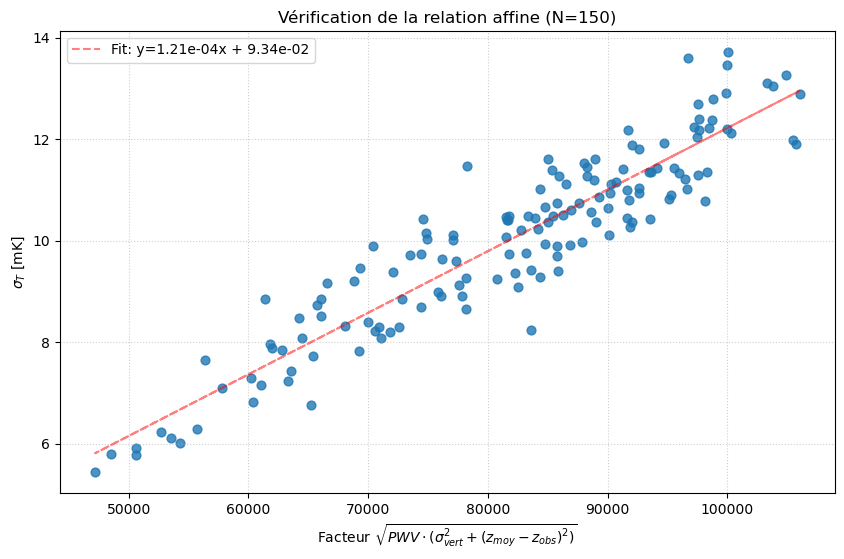

In [217]:
plt.figure(figsize=(10, 6))
plt.scatter(X_factor, sigma_T_res*1000, s=40, alpha=0.8)
#plt.colorbar(label='(z_moy-5000)^2 + std_vert^2 [m2]')

# Régression linéaire pour voir si c'est affine
coeffs = np.polyfit(X_factor, sigma_T_res*1000, 1)
poly = np.poly1d(coeffs)
plt.plot(X_factor, poly(X_factor), 'r--', alpha=0.5, label=f'Fit: y={coeffs[0]:.2e}x + {coeffs[1]:.2e}')

plt.title(f"Vérification de la relation affine (N={N_scenarios})")
plt.xlabel(r"Facteur $\sqrt{PWV \cdot (\sigma_{vert}^2 + (z_{moy} - z_{obs})^2)}$")
plt.ylabel(r"$\sigma_T$ [mK]")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [165]:
print(PWV_res/1000)

[1.5002628  1.73151337 1.90975119 1.64091488 0.82720296 1.72821224
 1.33185243 1.28103148 2.17768698 1.30823857 1.17518421 1.49769718
 1.96058112 1.30139435 1.9296098  1.36651006 1.08906251 1.30952576
 0.82566486 1.69750446 0.72979271 1.03734623 0.95332022 0.65700403
 1.70640174 2.17598583 1.71585781 2.22443938 1.48342281 1.84025904
 1.25210841 1.18118006 1.06956485 1.50366696 2.11604407 1.84284961
 1.00654306 1.15564837 0.97557796 2.16167829 1.94833326 1.88281588
 1.65540169 1.06056055 2.10830989 1.82975901 2.10746921 0.56586443
 1.58503278 1.45383655 1.2727947  1.98179222 1.0635628  1.88110503
 0.85545498 2.17642326 0.77198903 1.80315458 0.58568783 1.14665103
 1.57649137 1.96530781 0.70855529 0.27623997 2.08548632 1.61906082
 2.13302816 1.12548679 1.34629062 0.55733324 1.99380672 1.87649625
 1.15121442 1.63255671 1.59648522 1.60420467 0.9403038  1.79342137
 1.4990884  1.40614267 0.91709651 1.29910483 2.0166331  1.45327274
 1.48623303 1.9049149  1.37087071 1.85901425 1.63644155 1.3532

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/333018932.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


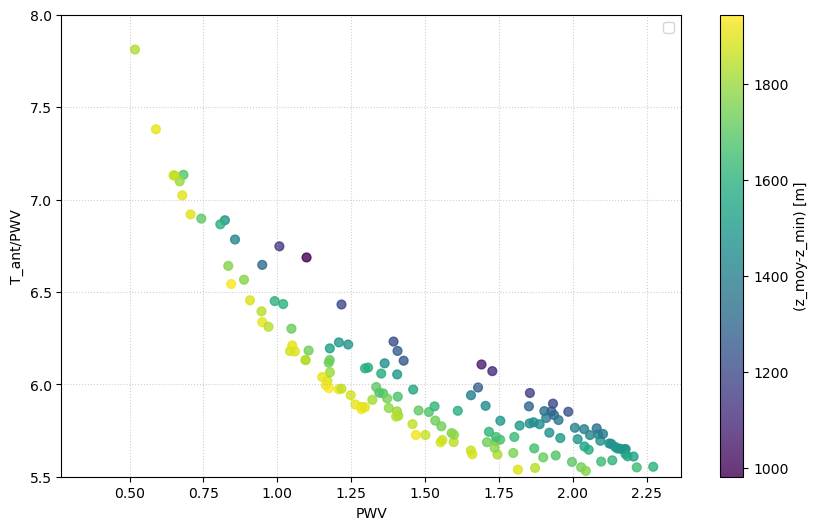

In [218]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(PWV_res/1000, T_ant_res/PWV_res*1000, c=((z_moy_res-Z_obs)), cmap='viridis', s=40, alpha=0.8)
plt.colorbar(label='(z_moy-z_min) [m]')

# Régression linéaire pour voir si c'est affine
coeffs = np.polyfit(X_factor, sigma_T_res, 1)
poly = np.poly1d(coeffs)
#plt.plot(X_factor, poly(X_factor), 'r--', alpha=0.5, label=f'Fit: y={coeffs[0]:.2e}x + {coeffs[1]:.2e}')

#plt.title(f"Vérification de la relation affine (N={N_scenarios})")
plt.xlabel("PWV")
plt.ylabel("T_ant/PWV")
plt.legend()
plt.ylim(5.5, 8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3899800132.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


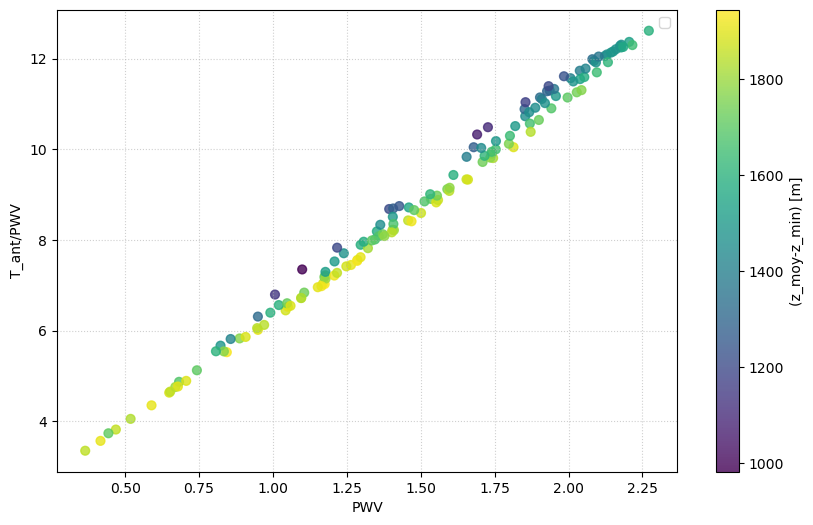

In [219]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(PWV_res/1000, T_ant_res, c=((z_moy_res-Z_obs)), cmap='viridis', s=40, alpha=0.8)
plt.colorbar(label='(z_moy-z_min) [m]')

# Régression linéaire pour voir si c'est affine
coeffs = np.polyfit(X_factor, sigma_T_res, 1)
poly = np.poly1d(coeffs)
#plt.plot(X_factor, poly(X_factor), 'r--', alpha=0.5, label=f'Fit: y={coeffs[0]:.2e}x + {coeffs[1]:.2e}')

#plt.title(f"Vérification de la relation affine (N={N_scenarios})")
plt.xlabel("PWV")
plt.ylabel("T_ant/PWV")
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3635436054.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


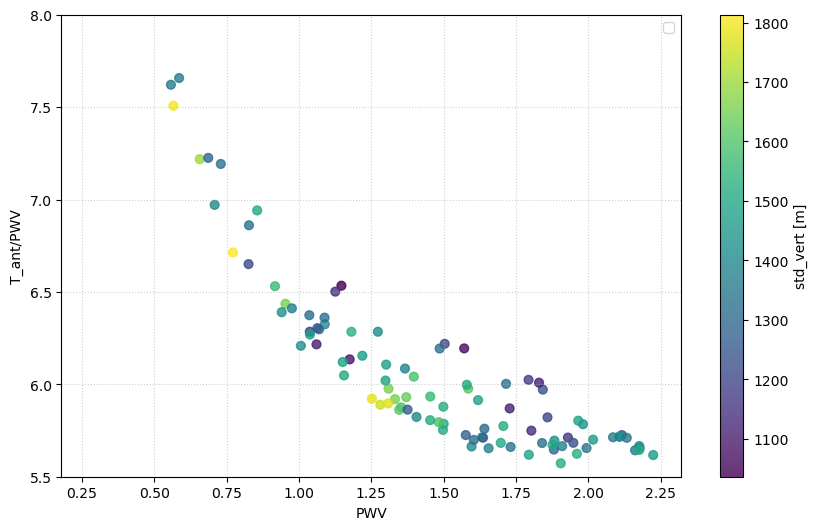

In [173]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(PWV_res/1000, T_ant_res/PWV_res*1000, c=((std_vert_res)), cmap='viridis', s=40, alpha=0.8)
plt.colorbar(label='std_vert [m]')

# Régression linéaire pour voir si c'est affine
coeffs = np.polyfit(X_factor, sigma_T_res, 1)
poly = np.poly1d(coeffs)
#plt.plot(X_factor, poly(X_factor), 'r--', alpha=0.5, label=f'Fit: y={coeffs[0]:.2e}x + {coeffs[1]:.2e}')

#plt.title(f"Vérification de la relation affine (N={N_scenarios})")
plt.xlabel("PWV")
plt.ylabel("T_ant/PWV")
plt.ylim(5.5,8)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

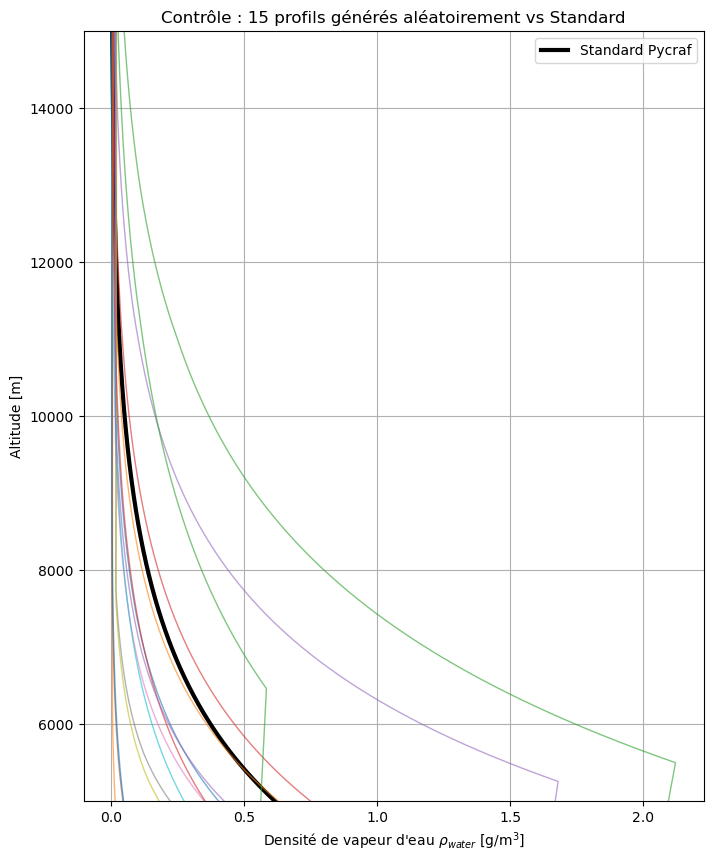

In [154]:
def modify_profile_shape(z, profile_base, stretch_factor, shift_offset):
    """
    Modifie la forme du profil par étirement et décalage.
    z : altitude cible
    profile_base : valeurs du profil standard aux altitudes z
    stretch_factor : > 1 étire vers le haut, < 1 compresse vers le sol
    shift_offset : décalage en mètres (+ monte, - descend)
    """
    # L'idée est de chercher quelle altitude 'z_src' du profil original 
    # correspond à l'altitude 'z' du nouveau profil.
    # z_new = z_src * stretch + shift
    # Donc : z_src = (z_new - shift) / stretch
    
    z_src = (z - shift_offset) / stretch_factor
    
    # On gère les bords : si z_src est en dessous de z_min (ex: shift positif), 
    # on peut soit mettre 0, soit extrapoler (ici on borne à z_min/z_max)
    z_src = np.clip(z_src, z.min(), z.max())
    
    # Interpolation sur le profil de base
    # profile_base est supposé défini sur z (qui est régulier ou l'axe de référence)
    new_vals = np.interp(z_src, z, profile_base)
    
    # Si on a décalé vers le haut, le bas est "vide" (ou rempli par la valeur au sol clipée).
    # Pour faire propre, on peut forcer 0 en dessous d'un seuil si shift > 0, 
    # mais l'interpolation 'clipée' répète la valeur du sol, ce qui est acceptable pour simuler une couche mixte.
    return new_vals

# --- Paramètres fixes ---
pi = np.pi     
frequency = np.array([150e9]) 
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 90
N_MC = 70
epsilon = 0.622
R_water = 461.5
Z_obs = 5000 # Altitude de l'observateur (pour votre formule)

# --- Grille Haute Résolution (z_1) pour la physique ---
z_1 = np.linspace(5000, 15000, 2000) # m
z_1_km = (z_1 * u.m).to(u.km)

# Profils de base Pycraf
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value
P_1 = profile[1].value
P_water_base = profile[3].value # Profil de forme de base

# --- Grille Réduite (zg) pour le calcul Monte Carlo (fixe mais conservatrice) ---
# On prend un z_break un peu plus haut (4000 au lieu de 2000) pour accommoder les profils étirés
z_break_fixe = 9000 
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
zg = hybrid_lin_geom(5000, z_break_fixe, 20000, N_lin=N_lin, N_geom=N_geom, gamma=2)

# Interpolation du T et P sur la grille réduite (supposés constants, seule l'eau bouge)
T_g = np.interp(zg, z_1, T_1)
P_g = np.interp(zg, z_1, P_1)

# --- Bloc de contrôle VISUEL (à lancer avant la grosse boucle) ---
plt.figure(figsize=(8, 10))

# Profil de référence (Pycraf standard)
rho_ref = (P_water_base * 100) / (R_water * T_1) * 1000
plt.plot(rho_ref, z_1, 'k-', linewidth=3, label='Standard Pycraf')

# Tirage de 10 exemples aléatoires pour contrôle
for k in range(15):
    # Mêmes paramètres que dans votre boucle
    amp = np.random.uniform(0.1, 5.0)    # Amplitude modérée pour le plot
    stretch = np.random.uniform(0.5, 1.5)
    shift = np.random.uniform(-2000, 200)
    
    # Génération
    P_mod = modify_profile_shape(z_1, P_water_base, stretch, shift)
    P_final = P_mod * amp
    rho_final = (P_final * 100) / (R_water * T_1) * 1000
    
    # Plot (rho en x, altitude en y)
    plt.plot(rho_final, z_1, alpha=0.6, linewidth=1)

plt.xlabel(r"Densité de vapeur d'eau $\rho_{water}$ [g/m$^3$]")
plt.ylabel("Altitude [m]")
plt.title("Contrôle : 15 profils générés aléatoirement vs Standard")
plt.grid(True)
plt.legend()
plt.ylim(5000, 15000) # Zoom sur la partie intéressante
plt.show()

Génération de 15 profils pour contrôle visuel...


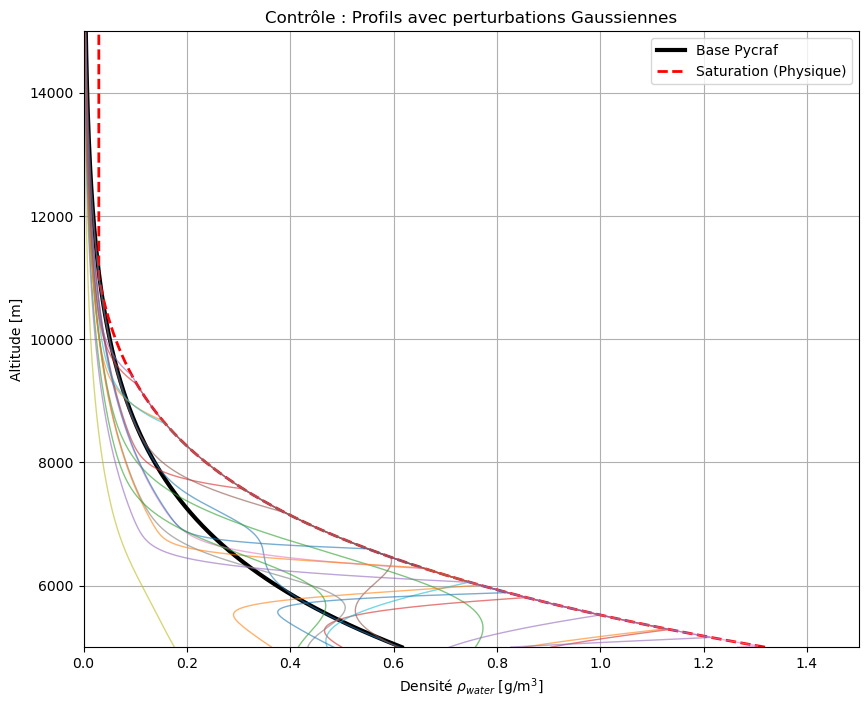

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# =============================================================================
# 1. PRÉPARATION : Limite Physique (Saturation)
# =============================================================================

# Formule de Magnus pour P_sat (hPa) en fonction de T (Celsius)
Tc = T_1 - 273.15
P_sat = 6.112 * np.exp((17.67 * Tc) / (Tc + 243.5))

# Conversion en densité max possible (g/m^3) pour le plot
rho_sat = (P_sat * 100) / (R_water * T_1) * 1000 

def add_gaussian_layer(z, profile_base, center_alt, width, amplitude):
    gaussian = amplitude * np.exp(-0.5 * ((z - center_alt) / width)**2)
    return profile_base + gaussian

# =============================================================================
# 2. CONTRÔLE VISUEL (Spaghetti Plot)
# =============================================================================

plt.figure(figsize=(10, 8))

# Plot du profil de base et de la limite de saturation
rho_base = (P_water_base * 100) / (R_water * T_1) * 1000
plt.plot(rho_base, z_1, 'k-', linewidth=3, label='Base Pycraf')
plt.plot(rho_sat, z_1, 'r--', linewidth=2, label='Saturation (Physique)')

print("Génération de 15 profils pour contrôle visuel...")

for k in range(15):
    # --- Tirage Aléatoire ---
    z_layer = np.random.uniform(5500, 7000)   # Altitude de la couche
    width_layer = np.random.uniform(200, 1000) # Épaisseur
    amp_layer = np.random.uniform(0.0, 2.5)    # Intensité (hPa)
    bg_scale = np.random.uniform(0.2, 1)     # Variation du fond
    
    # --- Construction ---
    P_base_scaled = P_water_base * bg_scale
    P_final = add_gaussian_layer(z_1, P_base_scaled, z_layer, width_layer, amp_layer)
    
    # --- Clipping Physique (Saturation) ---
    # On empêche l'eau de dépasser la saturation (ce qui créerait des nuages liquides, 
    # mais pour le délai on regarde surtout la vapeur)
    P_final = np.minimum(P_final, P_sat)
    
    # Conversion en densité
    rho_final = (P_final * 100) / (R_water * T_1) * 1000
    
    plt.plot(rho_final, z_1, alpha=0.6, linewidth=1)

plt.xlabel(r"Densité $\rho_{water}$ [g/m$^3$]")
plt.ylabel("Altitude [m]")
plt.title("Contrôle : Profils avec perturbations Gaussiennes")
plt.legend()
plt.grid(True)
plt.xlim(0, 1.5) # Ajustez selon vos valeurs typiques
plt.ylim(5000, 15000)
plt.show()

On teste ici l'apport du SNR sur la température 

In [ ]:
pi = np.pi     
frequency = np.array ([150e9]) # 150 GHz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
#altitudes = np.geomspace(1, 15001, 100) #m
altitudes = np.arange(5000,20000,30)
#altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

epsilon    = 0.622 # rapport des masses molaires de l'eau et de l'air sec

elev = 90 #en deg

WVMR = epsilon * P_water / (Pressure - P_water) #kg/kg
WVMR = WVMR *1000 #g/kg

N_MC = 200
N=500

sigma_wvmr = np.full(len(WVMR),0) #0 g/kg
sigma_T_phys = np.full(len(WVMR),0.5) #0.5 K

In [277]:
from src.cosmo_lidar.mc_tools import (monte_carlo_t_ant_2, predict_SNR_T_2)

In [303]:
print(altitudes)

[]


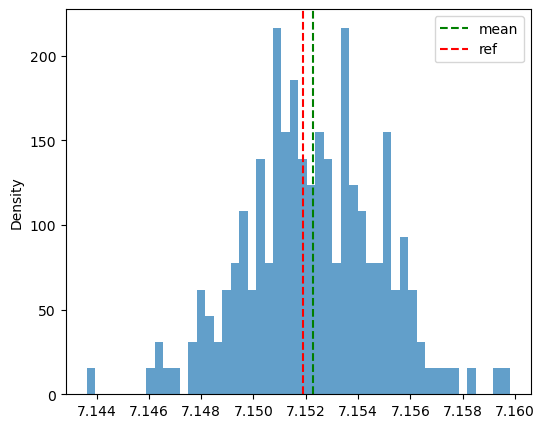

In [306]:
simu_s_T = monte_carlo_t_ant_2(frequency,theta_b, N, elev, generate_Pwater_MC_lognormal, generate_Pwater_MC, N_MC, WVMR, sigma_wvmr, Temperature, sigma_T_phys, Pressure, altitudes)

In [307]:
print(simu_s_T)

(np.float64(0.002588970906884017), array([7.15190231]))


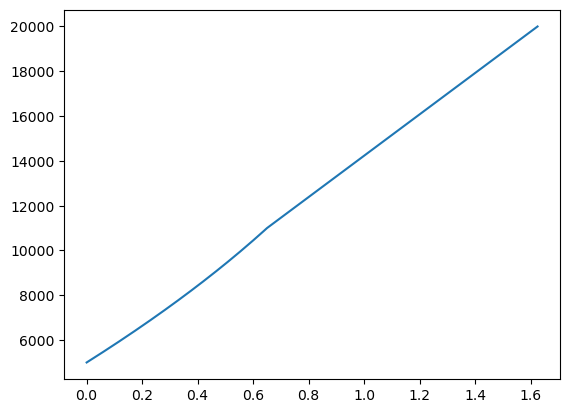

In [281]:
B = 1/2000000
sigma_T_phys = Temperature * B * (altitudes - altitudes[0])

plt.plot (sigma_T_phys, altitudes)

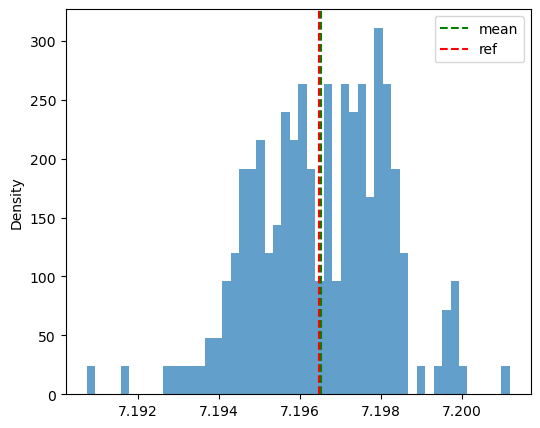

In [282]:
simu_s_T = monte_carlo_t_ant_2(frequency,theta_b, N, elev, generate_Pwater_MC_lognormal, generate_Pwater_MC, N_MC, WVMR, sigma_wvmr, Temperature, sigma_T_phys, Pressure, altitudes)

In [283]:
print(simu_s_T)

(np.float64(0.0016565065723386525), array([7.19646426]))


SNR sur l'eau

In [275]:
A = 106533.049 #parameter estimation SNR
c = 1.470303e-05 #parameter estimation SNR
WVMR = WVMR #g/kg
z_1 = altitudes #m
P_1 = Pressure #hPa
T_1 = Temperature #K
P_water_1 = P_water #hPa
SNR_1 = A*np.sqrt(WVMR * P_1 / T_1) / (z_1 - (z_1[0]-0.001)) * np.exp(-c * cumulative_trapezoid(P_1 / T_1, z_1, initial=0.0))
SNR_1 = scale_snr_for_variable_bins(z_1, SNR_1, elev = elev, dz_ref=30.0)[0]

sigma_wvmr_reel = WVMR / SNR_1

In [276]:
sigma_T_phys_nul = np.full(len(Temperature), 0)
sigma_wvmr_nul = np.full(len(WVMR), 0)

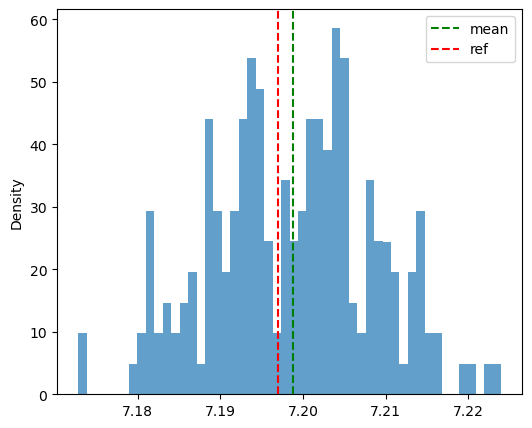

(np.float64(0.009826552873148818), array([7.19694713]))


In [269]:
simu_only_s_wvmr = monte_carlo_t_ant_2(frequency,theta_b, N, elev, generate_Pwater_MC_lognormal, 
                               generate_Pwater_MC, N_MC, WVMR, sigma_wvmr_reel, Temperature, 
                               sigma_T_phys_nul, Pressure, altitudes)
print(simu_only_s_wvmr)

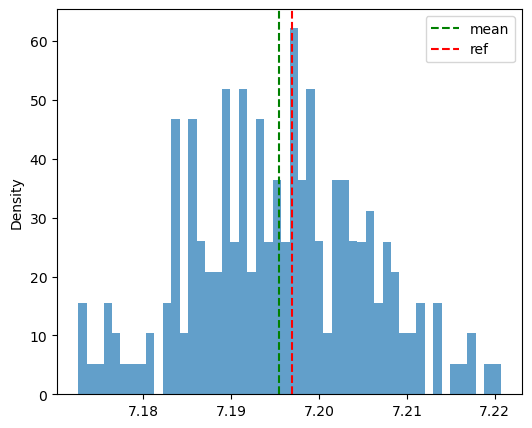

(np.float64(0.010006903595833467), array([7.19694713]))


In [270]:
simu_both = monte_carlo_t_ant_2(frequency,theta_b, N, elev, generate_Pwater_MC_lognormal, 
                               generate_Pwater_MC, N_MC, WVMR, sigma_wvmr_reel, Temperature, 
                               sigma_T_phys, Pressure, altitudes)
print(simu_both)

In [289]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid  # Pour l'intégration numérique
import matplotlib.pyplot as plt



# =============================================================================
# 2. INITIALISATION ET MAILLAGE HAUTE RÉSOLUTION (z_1)
# =============================================================================

# Paramètres généraux
pi = np.pi     
frequency = np.array([150e9]) # Hz
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 90
N_MC = 200
epsilon = 0.622
R_water = 461.5 # J/kg/K

# -- 2a. Création de la grille fine linéaire (z_1) --
# On prend large (ex: 2000 points) pour avoir une bonne précision sur z_moy et z_break
altitudes_hr = np.linspace(5000, 15000, 2000) # m
z_1 = altitudes_hr
z_1_km = (z_1 * u.m).to(u.km)

# -- 2b. Récupération des profils Pycraf sur la grille fine --
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        # K
P_1 = profile[1].value        # hPa
rho_water_1_base = profile[2].value # g/m^3 (Profil standard de base)
P_water_1_base = profile[3].value   # hPa (Profil standard de base)
B = 1/2000000
sigma_T_phys = Temperature * B * (altitudes + 0.01 - altitudes[0])
SNR_temperature = 1 / (B*(z_1+0.01-z_1[0]))

# =============================================================================
# 3. CRÉATION DE LA GRILLE RÉDUITE OPTIMISÉE (zg)
# =============================================================================

N_Z = 200
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
gamma = 2
Z_FLOOR = 5000

# Calcul du z_break sur le profil standard (la forme ne change pas avec le scaling)
z_break = calcul_z_percentile_wvc(z_1, rho_water_1_base, 90)
print(f"Altitude de coupure (90% eau) : {z_break:.1f} m")

zmin = max(float(np.nanmin(z_1)), Z_FLOOR)
zmax = float(np.nanmax(z_1))

# Génération du maillage réduit
zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)

# =============================================================================
# 4. BOUCLE DE CALCUL AVEC SCALING PWV
# =============================================================================

# Facteurs d'échelle PWV
x_scale = np.linspace(0.01, 1, 30)

# Tableaux pour stocker les résultats
sigma_T_results = np.zeros_like(x_scale)
T_ant_results = np.zeros_like(x_scale)
z_moy_results = np.zeros_like(x_scale)
std_vert_results = np.zeros_like(x_scale)
PWV_results = np.zeros_like(x_scale) # Pour vérification

print(f"Lancement de la simulation pour {len(x_scale)} points...")

for i, val in enumerate(x_scale):
    
    # --- A. Mise à l'échelle sur la grille HAUTE RÉSOLUTION (z_1) ---
    # On travaille sur z_1 pour calculer les intégrales (z_moy, std) avec précision
    
    P_water_1_scaled = P_water_1_base * val

    
    # --- C. Interpolation vers la grille RÉDUITE (zg) pour Monte Carlo ---
    
    # Interpolation des champs scalés depuis z_1 vers zg
    T_g = np.interp(zg, z_1, T_1)
    P_g = np.interp(zg, z_1, P_1)
    P_water_g = np.interp(zg, z_1, P_water_1_scaled)
    SNR_temperature_g = np.interp (zg, z_1, SNR_temperature)
    
    # Recalcul du WVMR sur la grille réduite
    # WVMR = epsilon * P_w / (P_dry) = epsilon * P_w / (P_tot - P_w)
    denom = P_g - P_water_g
    denom[denom <= 0] = 1e-6 # Sécurité numérique
    
    WVMR_g = epsilon * P_water_g / denom * 1000 # g/kg
    
    # --- D. Appel de la fonction de prédiction ---
    
    # On passe les vecteurs réduits (_g)
    sig, temp = predict_SNR_T_2(
        frequency=frequency,
        theta_b=theta_b,
        z=zg,           # Grille réduite
        WVMR=WVMR_g,    # Profil interpolé
        elev=elev,
        T=T_g,
        SNR_temperature = SNR_temperature_g,
        P=P_g,
        N_MC=N_MC
    )
    
    # Moyenne si la fonction retourne un array
    sigma_T_results[i] = np.mean(sig)
    T_ant_results[i] = np.mean(temp)

Altitude de coupure (90% eau) : 9487.4 m
Lancement de la simulation pour 30 points...


In [292]:
print(sigma_T_results, calcul_PWV(rho_water_1_base, z_1))

[0.00126553 0.00215757 0.00245583 0.00334742 0.00369632 0.00412345
 0.00475269 0.00482082 0.00502148 0.00544571 0.00579163 0.0061735
 0.00637764 0.00679548 0.00676196 0.00766833 0.00833895 0.00712581
 0.00801234 0.00854571 0.00842297 0.00902561 0.00833284 0.0089424
 0.00961531 0.00960704 0.00981593 0.01057991 0.01007385 0.01002057] 1222.979351411724


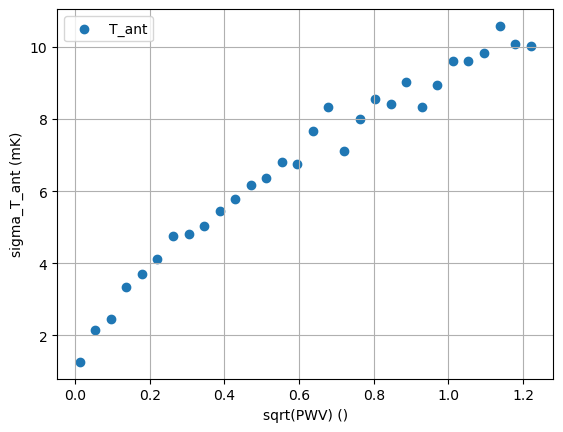

In [293]:
plt.figure()
plt.scatter(1.22*x_scale, sigma_T_results*1000, label="T_ant")
#plt.plot(z_max_list, sigma_list*1000, marker = 'o',label="sigma_T")
#plt.axvline(z_max_opt, linestyle="--", label=f"z_max_opt = {z_max_opt:.1f} m")
plt.xlabel("sqrt(PWV) ()")
plt.ylabel("sigma_T_ant (mK)")
plt.legend()
plt.grid(True, which="both")
plt.show()

<>:150: SyntaxWarning: invalid escape sequence '\p'
<>:150: SyntaxWarning: invalid escape sequence '\c'
<>:150: SyntaxWarning: invalid escape sequence '\p'
<>:150: SyntaxWarning: invalid escape sequence '\c'


/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3962631800.py:150: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Validation du lien $T_{{ant}} \propto T_{{eff}} \cdot PWV$ ({frequency[0]/1e9:.0f} GHz)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/3962631800.py:150: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f"Validation du lien $T_{{ant}} \propto T_{{eff}} \cdot PWV$ ({frequency[0]/1e9:.0f} GHz)")


Lancement de 150 simulations avec optimisation par interpolation...
Simulations terminées.


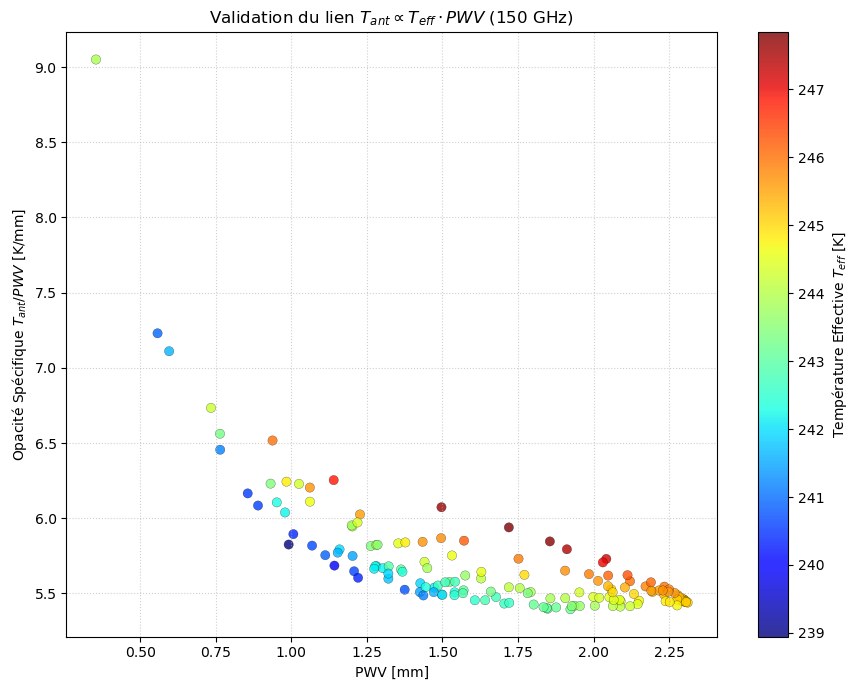

In [317]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# =============================================================================
# 1. FONCTIONS ET MAILLAGE HYBRIDE
# =============================================================================

def hybrid_lin_geom(zmin, zbreak, zmax, N_lin=80, N_geom=70, gamma=1.0):
    """Génère un maillage optimisé : dense en bas, lâche en haut."""
    z1 = np.linspace(zmin, zbreak, N_lin, endpoint=False)
    t = np.linspace(0, 1, N_geom)
    z2 = zbreak * (zmax / zbreak)**(t**gamma)
    return np.concatenate([z1, z2])

def add_gaussian_layer(z, profile_base, center_alt, width, amplitude):
    """Ajoute une couche gaussienne."""
    gaussian = amplitude * np.exp(-0.5 * ((z - center_alt) / width)**2)
    return profile_base + gaussian

# --- Paramètres ---
pi = np.pi     
frequency = np.array([150e9]) 
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 90
elevation_deg = 90
N_MC = 500 # Points d'intégration angulaire
epsilon = 0.622
R_water = 461.5

# --- 1a. Grille HAUTE RÉSOLUTION (z_1) pour la PHYSIQUE ---
# On s'assure d'aller assez haut pour que P_water tombe à 0
z_1 = np.linspace(5000, 20000, 2000) 
z_1_km = (z_1 * u.m).to(u.km)

# Profils Pycraf de référence (Haute Res)
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        
P_1 = profile[1].value        
P_water_base = profile[3].value 

# Saturation
Tc = T_1 - 273.15
P_sat = 6.112 * np.exp((17.67 * Tc) / (Tc + 243.5))

# --- 1b. Grille RÉDUITE (zg) pour le RADIATIF (Optimisation) ---
# On condense les points là où il y a de l'eau (5km -> 10km)
N_Z_low = 150
z_break = 10000 
N_lin = 4 * N_Z_low // 5
N_geom = N_Z_low - N_lin

zg = hybrid_lin_geom(5000, z_break, 20000, N_lin=N_lin, N_geom=N_geom, gamma=1.5)

# On pré-calcule T et P sur la grille réduite (car ils sont constants)
T_g = np.interp(zg, z_1, T_1)
P_g = np.interp(zg, z_1, P_1)

# =============================================================================
# 2. BOUCLE DE SIMULATION
# =============================================================================

N_scenarios = 150
T_ant_res = np.zeros(N_scenarios)
PWV_res = np.zeros(N_scenarios)
T_eff_res = np.zeros(N_scenarios)
z_moy_res = np.zeros(N_scenarios)
std_vert_res = np.zeros(N_scenarios)

print(f"Lancement de {N_scenarios} simulations avec optimisation par interpolation...")

for i in range(N_scenarios):
    
    # --- A. Génération sur Grille Fine (Physique précise) ---
    z_layer = np.random.uniform(5500, 8500)
    width_layer = np.random.uniform(200, 1500)
    amp_layer = np.random.uniform(0.0, 3.0) 
    bg_scale = np.random.uniform(0.2, 1.2)
    
    # Construction P_water sur z_1
    P_base_scaled = P_water_base * bg_scale
    P_water_fine = add_gaussian_layer(z_1, P_base_scaled, z_layer, width_layer, amp_layer)
    P_water_fine = np.minimum(P_water_fine, P_sat)
    
    # Densité sur z_1
    rho_water_fine = (P_water_fine * 100) / (R_water * T_1) * 1000 
    
    # --- B. Calcul des Stats Physiques (sur Grille Fine) ---
    current_PWV = trapezoid(rho_water_fine, z_1)
    if current_PWV < 1e-6: current_PWV = 1e-6
    
    # Barycentre et T_eff précis
    z_moy = trapezoid(rho_water_fine * z_1, z_1) / current_PWV
    var_vert = trapezoid(rho_water_fine * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    numerator_Teff = trapezoid(rho_water_fine * T_1, z_1)
    t_eff_val = numerator_Teff / current_PWV
    
    # Stockage
    PWV_res[i] = current_PWV / 1000 # mm
    z_moy_res[i] = z_moy
    std_vert_res[i] = std_vert
    T_eff_res[i] = t_eff_val
    
    # --- C. Interpolation vers Grille Réduite (zg) ---
    # C'est ici qu'on gagne du temps !
    P_water_g = np.interp(zg, z_1, P_water_fine)
    
    # --- D. Calcul Radiométrique (sur Grille Réduite) ---
    # Calcul_T_ant_1_el va intégrer sur 150 points au lieu de 2000
    t_ant_array = Calcul_T_ant_1_el(
        frequency=frequency,
        theta_b=theta_b,
        altitudes=zg,       # <--- Grille réduite
        Temperature=T_g,    # <--- Profil interpolé
        Pressure=P_g,       # <--- Profil interpolé
        P_water=P_water_g,  # <--- Profil interpolé
        elevation=elevation_deg,
        N=N_MC
    )
    
    T_ant_res[i] = t_ant_array[0]

print("Simulations terminées.")

# =============================================================================
# 3. VISUALISATION
# =============================================================================

plt.figure(figsize=(9, 7))

# Axe Y : Opacité spécifique (T_ant / PWV)
# On filtre les très petits PWV pour éviter les outliers visuels
mask = PWV_res > 0.05
pwv_plot = PWV_res[mask]
opacity_plot = T_ant_res[mask] / pwv_plot
teff_plot = T_eff_res[mask]

sc = plt.scatter(pwv_plot, opacity_plot, c=teff_plot, cmap='jet', s=45, alpha=0.8, edgecolor='k', linewidth=0.2)

cbar = plt.colorbar(sc)
cbar.set_label(r"Température Effective $T_{eff}$ [K]")

plt.xlabel("PWV [mm]")
plt.ylabel(r"Opacité Spécifique $T_{ant} / PWV$ [K/mm]")
plt.title(f"Validation du lien $T_{{ant}} \propto T_{{eff}} \cdot PWV$ ({frequency[0]/1e9:.0f} GHz)")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

<>:150: SyntaxWarning: invalid escape sequence '\p'
<>:150: SyntaxWarning: invalid escape sequence '\c'
<>:150: SyntaxWarning: invalid escape sequence '\p'
<>:150: SyntaxWarning: invalid escape sequence '\c'
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/4215486622.py:150: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Validation du lien $T_{{ant}} \propto T_{{eff}} \cdot PWV$ ({frequency[0]/1e9:.0f} GHz)")
/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_23063/4215486622.py:150: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f"Validation du lien $T_{{ant}} \propto T_{{eff}} \cdot PWV$ ({frequency[0]/1e9:.0f} GHz)")


Lancement de 150 simulations avec optimisation par interpolation...
Simulations terminées.


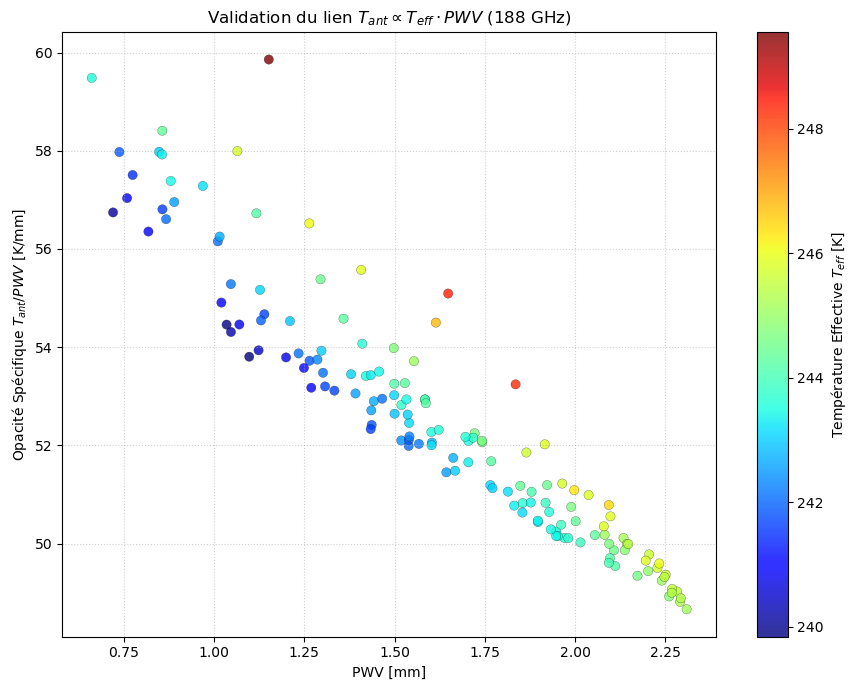

In [318]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# =============================================================================
# 1. FONCTIONS ET MAILLAGE HYBRIDE
# =============================================================================

def hybrid_lin_geom(zmin, zbreak, zmax, N_lin=80, N_geom=70, gamma=1.0):
    """Génère un maillage optimisé : dense en bas, lâche en haut."""
    z1 = np.linspace(zmin, zbreak, N_lin, endpoint=False)
    t = np.linspace(0, 1, N_geom)
    z2 = zbreak * (zmax / zbreak)**(t**gamma)
    return np.concatenate([z1, z2])

def add_gaussian_layer(z, profile_base, center_alt, width, amplitude):
    """Ajoute une couche gaussienne."""
    gaussian = amplitude * np.exp(-0.5 * ((z - center_alt) / width)**2)
    return profile_base + gaussian

# --- Paramètres ---
pi = np.pi     
frequency = np.array([188e9]) 
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elev = 90
elevation_deg = 90
N_MC = 500 # Points d'intégration angulaire
epsilon = 0.622
R_water = 461.5

# --- 1a. Grille HAUTE RÉSOLUTION (z_1) pour la PHYSIQUE ---
# On s'assure d'aller assez haut pour que P_water tombe à 0
z_1 = np.linspace(5000, 20000, 2000) 
z_1_km = (z_1 * u.m).to(u.km)

# Profils Pycraf de référence (Haute Res)
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        
P_1 = profile[1].value        
P_water_base = profile[3].value 

# Saturation
Tc = T_1 - 273.15
P_sat = 6.112 * np.exp((17.67 * Tc) / (Tc + 243.5))

# --- 1b. Grille RÉDUITE (zg) pour le RADIATIF (Optimisation) ---
# On condense les points là où il y a de l'eau (5km -> 10km)
N_Z_low = 150
z_break = 10000 
N_lin = 4 * N_Z_low // 5
N_geom = N_Z_low - N_lin

zg = hybrid_lin_geom(5000, z_break, 20000, N_lin=N_lin, N_geom=N_geom, gamma=1.5)

# On pré-calcule T et P sur la grille réduite (car ils sont constants)
T_g = np.interp(zg, z_1, T_1)
P_g = np.interp(zg, z_1, P_1)

# =============================================================================
# 2. BOUCLE DE SIMULATION
# =============================================================================

N_scenarios = 150
T_ant_res = np.zeros(N_scenarios)
PWV_res = np.zeros(N_scenarios)
T_eff_res = np.zeros(N_scenarios)
z_moy_res = np.zeros(N_scenarios)
std_vert_res = np.zeros(N_scenarios)

print(f"Lancement de {N_scenarios} simulations avec optimisation par interpolation...")

for i in range(N_scenarios):
    
    # --- A. Génération sur Grille Fine (Physique précise) ---
    z_layer = np.random.uniform(5500, 8500)
    width_layer = np.random.uniform(200, 1500)
    amp_layer = np.random.uniform(0.0, 3.0) 
    bg_scale = np.random.uniform(0.2, 1.2)
    
    # Construction P_water sur z_1
    P_base_scaled = P_water_base * bg_scale
    P_water_fine = add_gaussian_layer(z_1, P_base_scaled, z_layer, width_layer, amp_layer)
    P_water_fine = np.minimum(P_water_fine, P_sat)
    
    # Densité sur z_1
    rho_water_fine = (P_water_fine * 100) / (R_water * T_1) * 1000 
    
    # --- B. Calcul des Stats Physiques (sur Grille Fine) ---
    current_PWV = trapezoid(rho_water_fine, z_1)
    if current_PWV < 1e-6: current_PWV = 1e-6
    
    # Barycentre et T_eff précis
    z_moy = trapezoid(rho_water_fine * z_1, z_1) / current_PWV
    var_vert = trapezoid(rho_water_fine * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    numerator_Teff = trapezoid(rho_water_fine * T_1, z_1)
    t_eff_val = numerator_Teff / current_PWV
    
    # Stockage
    PWV_res[i] = current_PWV / 1000 # mm
    z_moy_res[i] = z_moy
    std_vert_res[i] = std_vert
    T_eff_res[i] = t_eff_val
    
    # --- C. Interpolation vers Grille Réduite (zg) ---
    # C'est ici qu'on gagne du temps !
    P_water_g = np.interp(zg, z_1, P_water_fine)
    
    # --- D. Calcul Radiométrique (sur Grille Réduite) ---
    # Calcul_T_ant_1_el va intégrer sur 150 points au lieu de 2000
    t_ant_array = Calcul_T_ant_1_el(
        frequency=frequency,
        theta_b=theta_b,
        altitudes=zg,       # <--- Grille réduite
        Temperature=T_g,    # <--- Profil interpolé
        Pressure=P_g,       # <--- Profil interpolé
        P_water=P_water_g,  # <--- Profil interpolé
        elevation=elevation_deg,
        N=N_MC
    )
    
    T_ant_res[i] = t_ant_array[0]

print("Simulations terminées.")

# =============================================================================
# 3. VISUALISATION
# =============================================================================

plt.figure(figsize=(9, 7))

# Axe Y : Opacité spécifique (T_ant / PWV)
# On filtre les très petits PWV pour éviter les outliers visuels
mask = PWV_res > 0.05
pwv_plot = PWV_res[mask]
opacity_plot = T_ant_res[mask] / pwv_plot
teff_plot = T_eff_res[mask]

sc = plt.scatter(pwv_plot, opacity_plot, c=teff_plot, cmap='jet', s=45, alpha=0.8, edgecolor='k', linewidth=0.2)

cbar = plt.colorbar(sc)
cbar.set_label(r"Température Effective $T_{eff}$ [K]")

plt.xlabel("PWV [mm]")
plt.ylabel(r"Opacité Spécifique $T_{ant} / PWV$ [K/mm]")
plt.title(f"Validation du lien $T_{{ant}} \propto T_{{eff}} \cdot PWV$ ({frequency[0]/1e9:.0f} GHz)")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

We want to study the evolution of the transmission as a function of PWV and the frequency

In [329]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
#on va calculer la temperature d'antenne
pi = np.pi     
frequency = np.linspace(1.e9 , 350.e9 , 2000) #Hz
wavelength = 3.e8 / frequency #m
theta_b = np.full(len(frequency), 1*60*pi/(2*180*3600))
elevation = 90
altitudes = np.geomspace(1, 15001, 1000) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

In [330]:
alpha = alpha_specific_function(altitudes, frequency, Temperature, Pressure ,P_water)
tau = optical_depth_emission (altitudes, alpha)
transmission = np.exp(-tau)

In [310]:
print(transmission.shape)

(1000, 401)


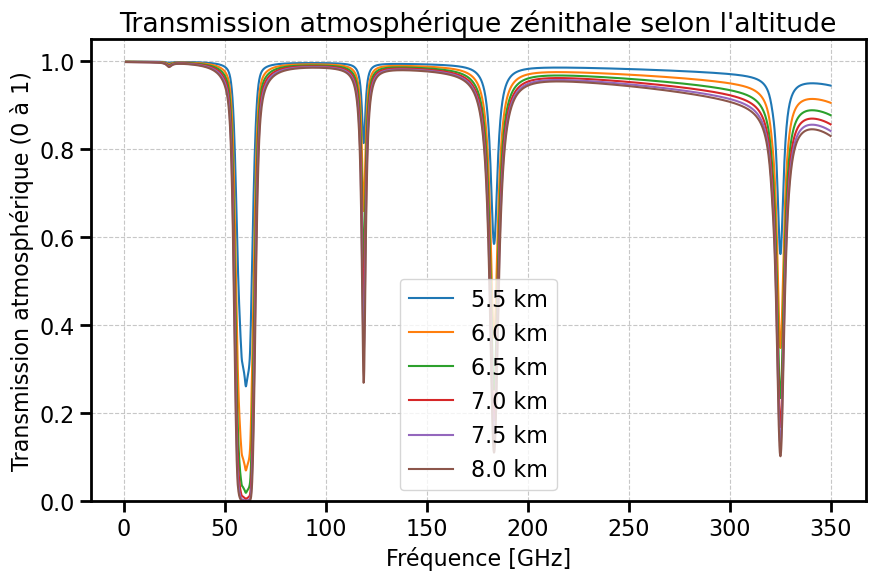

In [331]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Conversion de la fréquence en GHz pour l'affichage (plus lisible)
freq_GHz = frequency / 1e9 

# 2. Sélection des altitudes à tracer
# On ne veut pas tracer les 1000 courbes. On en choisit quelques-unes.
# Par exemple : indice 0 (le plus bas), et quelques autres répartis
#indices_to_plot = [0, 100, 300, 600, 999] 

# Ou alternativement, choisir des altitudes proches de valeurs rondes (ex: 5km, 8km, 12km) :
target_alts = [5500, 6000, 6500, 7000, 7500, 8000]
indices_to_plot = [np.abs(altitudes - z).argmin() for z in target_alts]

plt.figure(figsize=(10, 6))

# 3. Boucle de tracé
for idx in indices_to_plot:
    # On récupère l'altitude correspondante (en km pour la légende)
    alt_km = altitudes[idx] / 1000
    
    # On trace : X = Fréquence, Y = Transmission à l'altitude idx
    # transmission[idx, :] signifie : toutes les fréquences pour l'altitude idx
    plt.plot(freq_GHz, transmission[idx, :], label=f'{alt_km:.1f} km')

# 4. Mise en forme du graphique
plt.xlabel('Fréquence [GHz]')
plt.ylabel('Transmission atmosphérique (0 à 1)')
plt.title('Transmission atmosphérique zénithale selon l\'altitude')
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0, 1.05) # La transmission est entre 0 et 1

# Optionnel : marquer les raies d'absorption principales
# O2 à 118 GHz et H2O à 183 GHz, 325 GHz, etc.
# plt.axvline(118.75, color='gray', linestyle=':', alpha=0.5)
# plt.axvline(183.31, color='gray', linestyle=':', alpha=0.5)

plt.show()

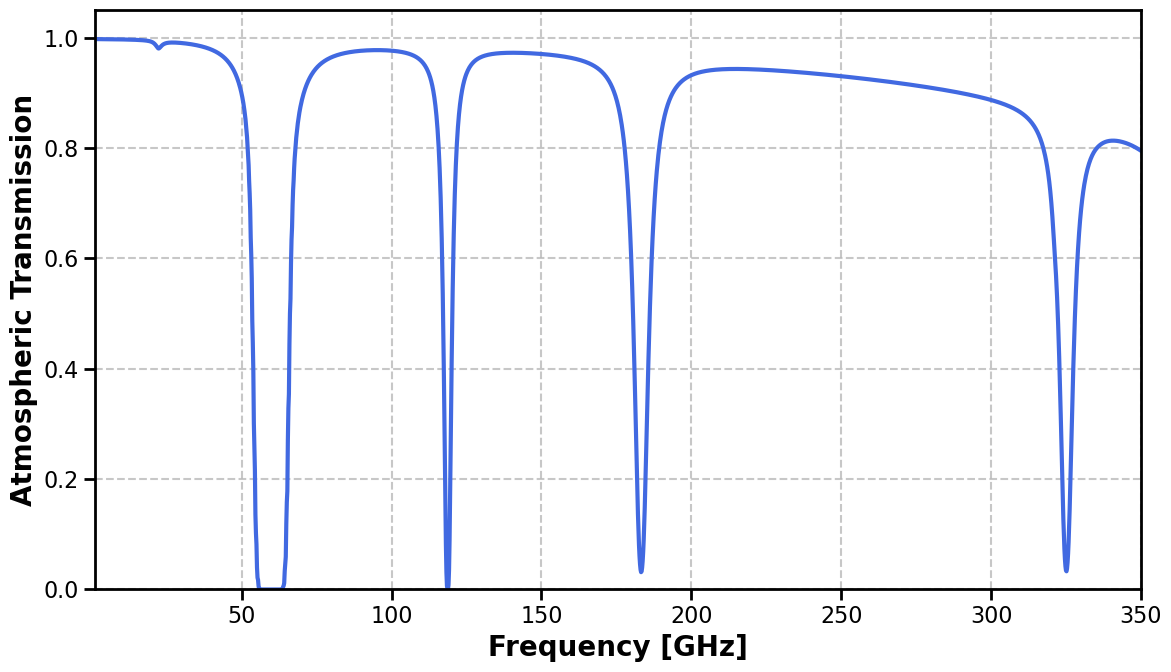

In [332]:
import matplotlib.pyplot as plt

# 1. Configuration globale (Astuce : définit la taille par défaut pour tout)
plt.rcParams.update({
    'font.size': 16,          # Taille du texte par défaut
    'axes.linewidth': 2,      # Epaisseur du cadre
    'xtick.major.size': 8,    # Taille des tirets sur X
    'xtick.major.width': 2,   # Epaisseur des tirets sur X
    'ytick.major.size': 8,    # Taille des tirets sur Y
    'ytick.major.width': 2,   # Epaisseur des tirets sur Y
})

plt.figure(figsize=(12, 7)) # Format 16:9 adapté aux écrans

# 2. Le tracé : Ligne plus épaisse (linewidth=3 ou 4)
plt.plot(freq_GHz, transmission[-1,:], 
         linewidth=3, 
         color='royalblue',  # Couleur vive qui passe bien sur projecteur
         label='Transmission zenith') 

# 3. Les Labels : Très gros et en gras
plt.xlabel('Frequency [GHz]', fontsize=20, fontweight='bold')
plt.ylabel('Atmospheric Transmission', fontsize=20, fontweight='bold')
#plt.title('Transmission Atmosphérique', fontsize=24, pad=20, fontweight='bold')

# 4. Gestion des axes
plt.ylim(0, 1.05) # On fixe les limites logiques (0 à 1)
plt.xlim(freq_GHz.min(), freq_GHz.max())

# 5. Grille : Visible mais discrète (pour ne pas surcharger la slide)
plt.grid(True, linestyle='--', alpha=0.7, linewidth=1.5)

# (Optionnel) Ajout d'une zone de couleur si tu veux montrer que c'est opaque
# plt.fill_between(freq_GHz, transmission[-1,:], alpha=0.2, color='royalblue')

plt.tight_layout() # Évite que les labels soient coupés lors de la sauvegarde
plt.show()


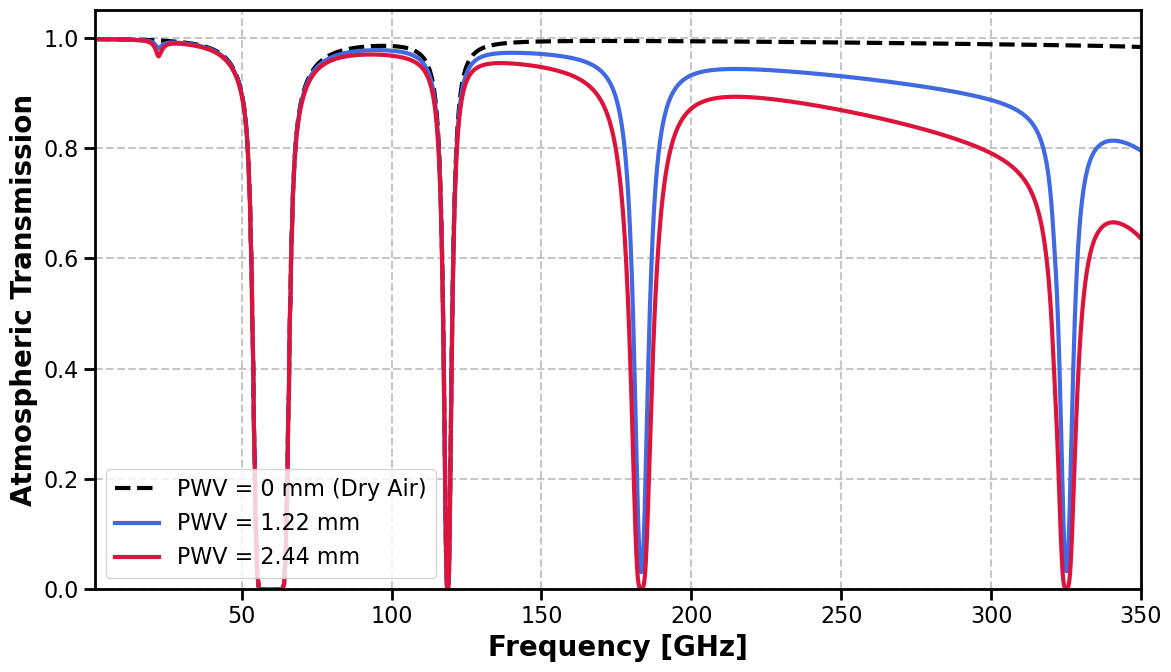

In [334]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration globale (Style Présentation) ---
plt.rcParams.update({
    'font.size': 16,
    'axes.linewidth': 2,
    'xtick.major.size': 8,
    'xtick.major.width': 2,
    'ytick.major.size': 8,
    'ytick.major.width': 2,
})

# --- 2. Définition des scénarios PWV ---
# PWV de référence du profil standard (environ 1.22 mm pour le profil mid-lat summer standard souvent)
# Si ton profil P_water correspond à 1.22 mm, alors :
pwv_ref = 1.22 
target_pwvs = [0.000000000000000001, 1.22, 2.44] # mm
colors = ['black', 'royalblue', 'crimson'] # Couleurs distinctes (Sec, Standard, Humide)
labels = ['0 mm (Dry Air)', '1.22 mm', '2.44 mm']
linestyles = ['--', '-', '-'] # Le cas sec en pointillé pour le différencier

plt.figure(figsize=(12, 7))

# --- 3. Boucle de Calcul et Tracé ---

for i, pwv_val in enumerate(target_pwvs):
    
    # Calcul du facteur d'échelle par rapport au profil de base
    # Si pwv_val = 0, factor = 0. Si pwv_val = 2.44, factor = 2.0
    factor = pwv_val / pwv_ref
    
    # A. Modification du profil physique
    P_water_mod = P_water * factor
    
    # B. Recalcul de la transmission (Alpha -> Tau -> Transmission)
    # On suppose que tu as tes fonctions physiques disponibles
    alpha_mod = alpha_specific_function(altitudes, frequency, Temperature, Pressure, P_water_mod)
    tau_mod = optical_depth_emission(altitudes, alpha_mod)
    trans_mod = np.exp(-tau_mod)
    
    # C. Tracé de la courbe (Transmission au sommet de l'atmosphère : indice -1)
    plt.plot(freq_GHz, trans_mod[-1, :], 
             linewidth=3, 
             color=colors[i],
             linestyle=linestyles[i],
             label=f'PWV = {labels[i]}')


# --- 4. Mise en forme des axes et légende ---
plt.xlabel('Frequency [GHz]', fontsize=20, fontweight='bold')
plt.ylabel('Atmospheric Transmission', fontsize=20, fontweight='bold')

# Limites
plt.ylim(0, 1.05)
plt.xlim(freq_GHz.min(), freq_GHz.max())

# Grille
plt.grid(True, linestyle='--', alpha=0.7, linewidth=1.5)

# Légende (Essentielle ici pour distinguer les courbes)
# frameon=True met un cadre blanc pour que le texte soit lisible par dessus les courbes
plt.legend(fontsize=16, frameon=True, loc='lower left')

plt.tight_layout()
plt.show()

Calcul en cours pour la fréquence cible : 188.00 GHz...


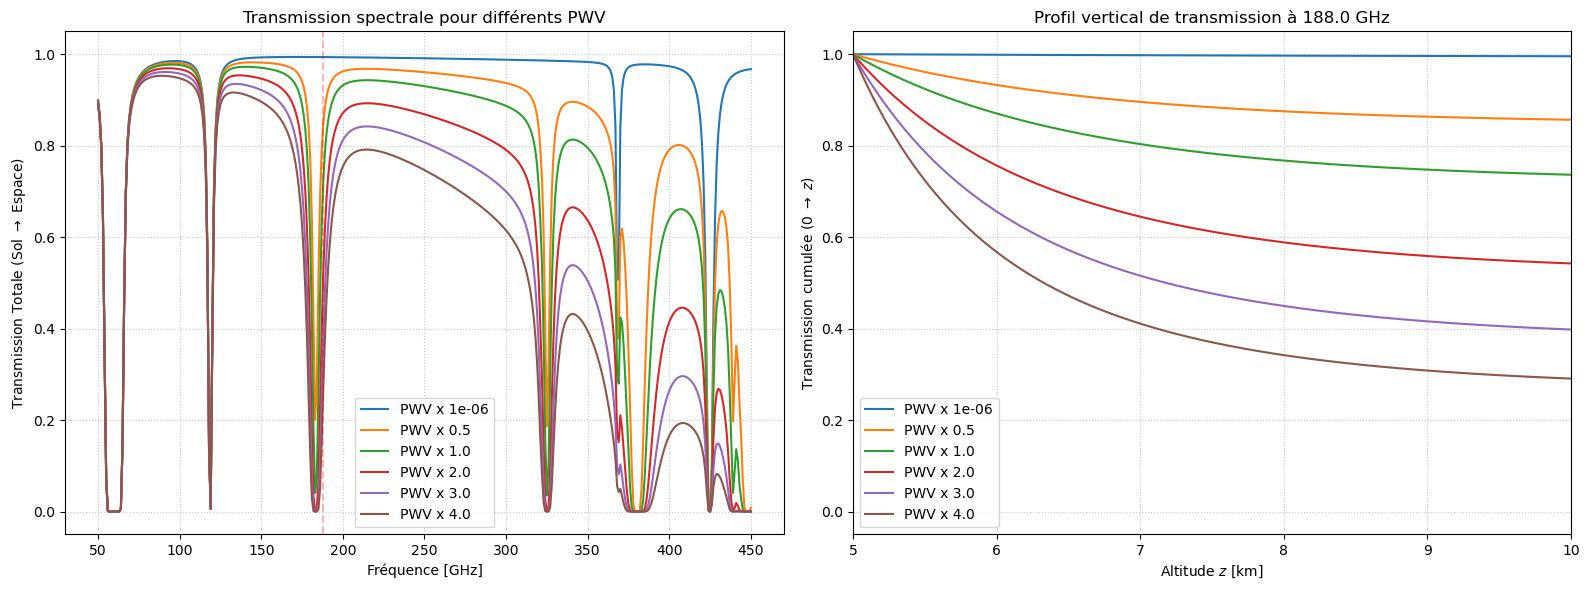

In [315]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Paramètres de l'étude ---

# Facteurs multiplicatifs du profil standard d'eau (pour simuler différents PWV)
# 0.0 = Air sec, 1.0 = Standard, 3.0 = Très humide
pwv_factors = [0.000001, 0.5, 1.0, 2.0, 3.0, 4.0] 

# Choix de la fréquence pour le 2ème graphique
target_freq_Hz = 188e9  # 150 GHz
# On trouve l'indice de la fréquence la plus proche dans votre tableau
idx_f = np.argmin(np.abs(frequency - target_freq_Hz))
freq_label = frequency[idx_f] / 1e9

# --- 2. Initialisation des Figures ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- 3. Boucle de Calcul ---

print(f"Calcul en cours pour la fréquence cible : {freq_label:.2f} GHz...")

for factor in pwv_factors:
    # A. Modification du profil d'eau
    P_water_mod = P_water * factor
    
    # B. Recalcul de la physique atmosphérique
    # On suppose que vous avez accès à vos fonctions 'alpha_specific_function' et 'optical_depth_emission'
    # Recalcul de l'atténuation locale
    alpha_mod = alpha_specific_function(altitudes, frequency, Temperature, Pressure, P_water_mod)
    
    # Recalcul de l'épaisseur optique intégrée (tau)
    # tau est de shape (len(altitudes), len(frequency))
    tau_mod = optical_depth_emission(altitudes, alpha_mod)
    
    # Recalcul de la transmission
    trans_mod = np.exp(-tau_mod)
    
    # --- GRAPHIQUE 1 : Transmission totale (z_max) vs Fréquence ---
    # On prend la dernière ligne (indice -1) qui correspond à la transmission depuis le sol jusqu'à z_max
    # trans_total_spectrum : tableau 1D de taille len(frequency)
    trans_total_spectrum = trans_mod[-1, :]
    
    label_pwv = f"PWV x {factor}" if factor > 0 else "Air Sec (PWV=0)"
    ax1.plot(frequency / 1e9, trans_total_spectrum, label=label_pwv)

    # --- GRAPHIQUE 2 : Transmission vs Altitude (à fréquence fixe) ---
    # On prend la colonne correspondant à idx_f
    # trans_profile : tableau 1D de taille len(altitudes)
    trans_profile = trans_mod[:, idx_f]
    
    # On convertit l'altitude en km pour l'affichage
    ax2.plot(altitudes / 1000, trans_profile, label=label_pwv)


# --- 4. Mise en forme ---

# Graphe 1
ax1.set_xlabel("Fréquence [GHz]")
ax1.set_ylabel("Transmission Totale (Sol $\\rightarrow$ Espace)")
ax1.set_title(f"Transmission spectrale pour différents PWV")
ax1.grid(True, which="both", linestyle=':', alpha=0.7)
ax1.legend()
ax1.set_ylim(-0.05, 1.05)
# Optionnel : marquer la fréquence choisie pour le graphe 2
ax1.axvline(freq_label, color='red', linestyle='--', alpha=0.3, label='Fréq. Graphe 2')


# Graphe 2
ax2.set_xlabel("Altitude $z$ [km]")
ax2.set_ylabel(f"Transmission cumulée (0 $\\rightarrow$ $z$)")
ax2.set_title(f"Profil vertical de transmission à {freq_label:.1f} GHz")
ax2.grid(True, which="both", linestyle=':', alpha=0.7)
ax2.legend()
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(5, 10)

plt.tight_layout()
plt.show()

Calcul des profils de transmission...


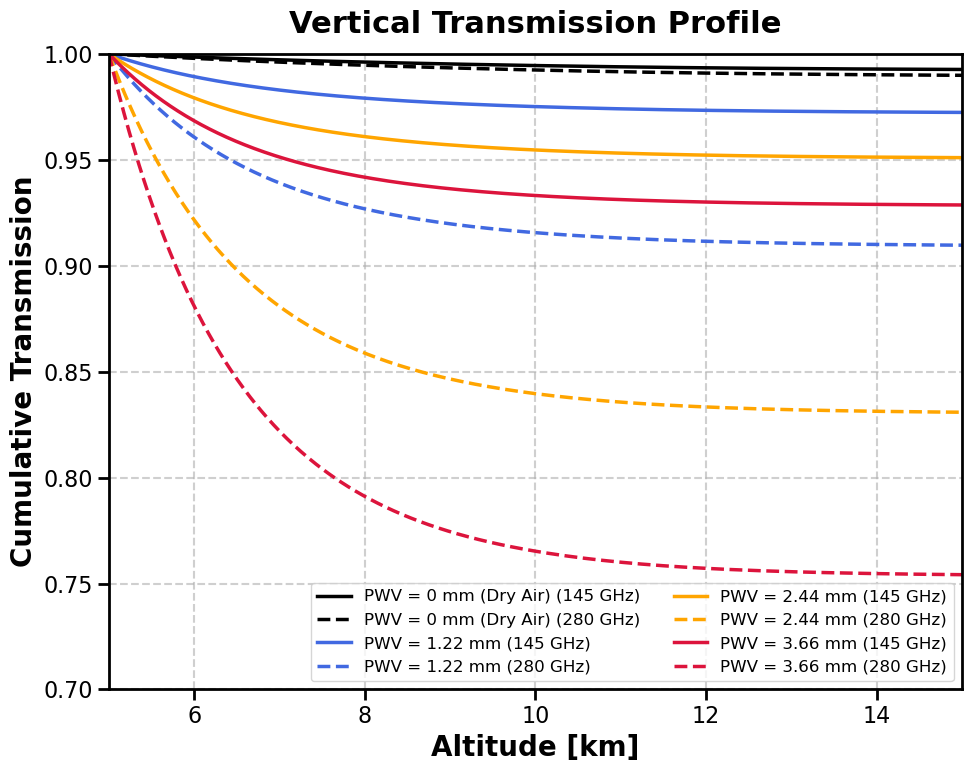

In [339]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration globale (Style Présentation) ---
plt.rcParams.update({
    'font.size': 16,
    'axes.linewidth': 2,
    'xtick.major.size': 8,
    'xtick.major.width': 2,
    'ytick.major.size': 8,
    'ytick.major.width': 2,
})

# --- 2. Paramètres de l'étude ---
pwv_factors = [0.00000001, 1, 2, 3]       # Facteurs demandés
pwv_ref_mm = 1.22                # Valeur de base (Factor 1)

target_freqs = [145e9, 280e9]    # Fréquences cibles
linestyles = ['-', '--']         # Plein pour 145, Pointillé pour 280
freq_labels = ["145 GHz", "280 GHz"]

# Couleurs pour les PWV (Noir, Bleu, Orange, Rouge)
colors = ['black', 'royalblue', 'orange', 'crimson']
labels = ['0 mm (Dry Air)', '1.22 mm', '2.44 mm', '3.66 mm']

# --- 3. Initialisation de la Figure ---
plt.figure(figsize=(10, 8))

# --- 4. Boucle de Calcul ---
print("Calcul des profils de transmission...")

for i, factor in enumerate(pwv_factors):
    
    # A. Modification du profil d'eau
    P_water_mod = P_water * factor
    current_pwv_mm = factor * pwv_ref_mm
    
    # B. Recalcul de la physique (Alpha -> Tau -> Transmission)
    alpha_mod = alpha_specific_function(altitudes, frequency, Temperature, Pressure, P_water_mod)
    tau_mod = optical_depth_emission(altitudes, alpha_mod)
    trans_mod = np.exp(-tau_mod)
    
    # C. Boucle sur les deux fréquences
    for j, f_target in enumerate(target_freqs):
        
        # Trouver l'indice de la fréquence la plus proche
        idx_f = np.argmin(np.abs(frequency - f_target))
        
        # Extraction du profil vertical pour cette fréquence
        trans_profile = trans_mod[:, idx_f]
        
        # D. Tracé
        # On ne met le label PWV que pour la première fréquence pour ne pas surcharger la légende
        # ou on combine tout. Ici, combinons pour la clarté.
        label_curve = f"PWV = {labels[i]} ({freq_labels[j]})"
        
        # Astuce pour la légende : on peut simplifier en ne mettant que les couleurs
        # Mais ici je mets tout pour être explicite
        plt.plot(altitudes / 1000, trans_profile, 
                 color=colors[i], 
                 linestyle=linestyles[j], 
                 linewidth=2.5,
                 label=label_curve)

# --- 5. Mise en forme ---
plt.xlabel('Altitude [km]', fontsize=20, fontweight='bold')
plt.ylabel('Cumulative Transmission', fontsize=20, fontweight='bold')
plt.title(f'Vertical Transmission Profile', fontsize=22, fontweight='bold', pad=15)

# Limites
plt.ylim(0.70, 1.0)
plt.xlim(altitudes.min()/1000, 15) # On zoome sur la zone pertinente (5-15km ou 0-15km selon ton altitude de départ)

plt.grid(True, which="both", linestyle='--', alpha=0.6, linewidth=1.5)

# Légende
# Pour éviter d'avoir 8 lignes, on peut la placer intelligemment
# ou utiliser ncol=2 pour faire deux colonnes
plt.legend(fontsize=12, loc='lower right', frameon=True, ncol=2)

plt.tight_layout()
plt.show()